# ***Week 1 DATA PREPROCESSING***
#### ***Loading Pickup Data***

In [ ]:
import pandas as pd

data_pickup_cq = pd.read_csv("Pickup Five Cities Datasets//pickup_cq.csv")
data_pickup_hz = pd.read_csv("Pickup Five Cities Datasets//pickup_hz.csv")
data_pickup_jl = pd.read_csv("Pickup Five Cities Datasets//pickup_jl.csv")
data_pickup_sh = pd.read_csv("Pickup Five Cities Datasets//pickup_sh.csv")
data_pickup_yt = pd.read_csv("Pickup Five Cities Datasets//pickup_yt.csv")

#### ***Check Column Consistency***

In [ ]:
col_map = {
    'cq': data_pickup_cq.columns,
    'hz': data_pickup_hz.columns,
    'jl': data_pickup_jl.columns,
    'sh': data_pickup_sh.columns,
    'yt': data_pickup_yt.columns,
}

col_merged_pickup_clean = pd.DataFrame(dict((k, pd.Series(v)) for k, v in col_map.items()))
col_merged_pickup_clean['all_same'] = col_merged_pickup_clean.nunique(axis=1) == 1
col_merged_pickup_clean

,cq,hz,jl,sh,yt,all_same
0,order_id,order_id,order_id,order_id,order_id,True
1,region_id,region_id,region_id,region_id,region_id,True
2,city,city,city,city,city,True
3,courier_id,courier_id,courier_id,courier_id,courier_id,True
4,accept_time,accept_time,accept_time,accept_time,accept_time,True
5,time_window_start,time_window_start,time_window_start,time_window_start,time_window_start,True
6,time_window_end,time_window_end,time_window_end,time_window_end,time_window_end,True
7,lng,lng,lng,lng,lng,True
8,lat,lat,lat,lat,lat,True
9,aoi_id,aoi_id,aoi_id,aoi_id,aoi_id,True


#### ***Merging Data***

In [ ]:
merged_map = [
    data_pickup_cq,
    data_pickup_hz,
    data_pickup_jl,
    data_pickup_sh,
    data_pickup_yt,
]

merged_pickup = pd.concat(merged_map, ignore_index=True, sort=False)
merged_pickup.sample(5)

,order_id,region_id,city,courier_id,accept_time,time_window_start,time_window_end,lng,lat,aoi_id,aoi_type,pickup_time,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,accept_gps_time,accept_gps_lng,accept_gps_lat,ds
4024319,1771399,20,Shanghai,530,09-04 08:59:00,09-04 13:00:00,09-04 15:00:00,121.48845,31.30601,20673,1,09-04 14:10:00,NaN,NaN,NaN,09-04 08:59:00,121.48781,31.30921,904
861334,1556001,86,Chongqing,6476,09-27 08:12:00,09-27 09:00:00,09-27 11:00:00,106.47964,29.47467,17172,0,09-27 10:15:00,NaN,NaN,NaN,NaN,NaN,NaN,927
2192774,5289938,68,Hangzhou,76,06-12 13:58:00,06-12 15:00:00,06-12 17:00:00,120.25527,30.15827,4284,1,06-12 16:38:00,NaN,NaN,NaN,NaN,NaN,NaN,612
2029310,5246363,65,Hangzhou,12687,08-23 07:40:00,08-23 09:00:00,08-23 11:00:00,120.03494,30.25135,17917,1,08-23 09:29:00,08-23 09:29:00,120.03465,30.25140,08-23 07:40:00,120.02351,30.21084,823
2127163,1920931,66,Hangzhou,9960,09-23 07:59:00,09-23 09:00:00,09-23 11:00:00,120.19651,30.19072,15860,2,09-23 09:24:00,09-23 09:24:00,120.19626,30.19092,NaN,NaN,NaN,923



***Handle missing values***

In [ ]:
null_counts = merged_pickup.isnull().sum()
null_percentages = round(merged_pickup.isnull().sum() / len(merged_pickup) * 100, 2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percentage': null_percentages
})

null_summary

,null_count,null_percentage
order_id,0,0.00
region_id,0,0.00
city,0,0.00
courier_id,0,0.00
accept_time,0,0.00
time_window_start,0,0.00
time_window_end,0,0.00
lng,0,0.00
lat,0,0.00
aoi_id,0,0.00


In [ ]:
merged_pickup.head()

,order_id,region_id,city,courier_id,accept_time,time_window_start,time_window_end,lng,lat,aoi_id,aoi_type,pickup_time,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,accept_gps_time,accept_gps_lng,accept_gps_lat,ds
0,483671,3,Chongqing,1518,08-14 07:57:00,08-14 09:00:00,08-14 11:00:00,106.46877,29.47204,218,14,08-14 09:38:00,NaN,NaN,NaN,NaN,NaN,NaN,814
1,1746131,3,Chongqing,4706,10-09 07:46:00,10-09 09:00:00,10-09 11:00:00,106.46872,29.47200,218,14,10-09 09:42:00,NaN,NaN,NaN,NaN,NaN,NaN,1009
2,2301722,3,Chongqing,4706,10-09 13:57:00,10-09 13:57:00,10-09 15:57:00,106.46869,29.47191,218,14,10-09 15:53:00,10-09 15:53:00,106.46821,29.46771,10-09 13:56:00,106.46929,29.47231,1009
3,3788723,3,Chongqing,4706,05-19 08:13:00,05-19 11:00:00,05-19 13:00:00,106.46878,29.47208,218,14,05-19 11:59:00,NaN,NaN,NaN,NaN,NaN,NaN,519
4,713435,3,Chongqing,4706,05-22 08:16:00,05-22 09:00:00,05-22 11:00:00,106.46813,29.47228,218,14,05-22 10:40:00,05-22 10:40:00,106.46827,29.47270,NaN,NaN,NaN,522


If >5% missing: Consider removing or filling with external data.

In [ ]:
merged_pickup_clean = merged_pickup.copy()

pickup_centroids = (
    merged_pickup_clean
    .groupby("aoi_id")[["pickup_gps_lng", "pickup_gps_lat"]]
    .mean()
    .rename(columns={
        "pickup_gps_lng": "centroid_pickup_lng",
        "pickup_gps_lat": "centroid_pickup_lat"
    })
)

accept_centroids = (
    merged_pickup_clean
    .groupby("aoi_id")[["accept_gps_lng", "accept_gps_lat"]]
    .mean()
    .rename(columns={
        "accept_gps_lng": "centroid_accept_lng",
        "accept_gps_lat": "centroid_accept_lat"
    })
)

centroids = (
    pickup_centroids
    .join(accept_centroids, how="outer")
    .reset_index()
)

merged_pickup_clean = merged_pickup_clean.merge(centroids, on="aoi_id", how="left")

merged_pickup_clean["pickup_gps_lng"] = merged_pickup_clean["pickup_gps_lng"].fillna(merged_pickup_clean["centroid_pickup_lng"])
merged_pickup_clean["pickup_gps_lat"] = merged_pickup_clean["pickup_gps_lat"].fillna(merged_pickup_clean["centroid_pickup_lat"])
merged_pickup_clean["accept_gps_lng"] = merged_pickup_clean["accept_gps_lng"].fillna(merged_pickup_clean["centroid_accept_lng"])
merged_pickup_clean["accept_gps_lat"] = merged_pickup_clean["accept_gps_lat"].fillna(merged_pickup_clean["centroid_accept_lat"])


merged_pickup_clean = merged_pickup_clean.drop([
    "centroid_pickup_lng", "centroid_pickup_lat",
    "centroid_accept_lng", "centroid_accept_lat"
], axis=1)

In [ ]:
for col in ['pickup_time','pickup_gps_time','accept_time','accept_gps_time']:
    merged_pickup_clean[col] = pd.to_datetime(
        "2025-" + merged_pickup_clean[col],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )

avg_pickup_lag = (merged_pickup_clean['pickup_gps_time'] - merged_pickup_clean['pickup_time']).dt.total_seconds().mean()
avg_accept_lag = (merged_pickup_clean['accept_gps_time'] - merged_pickup_clean['accept_time']).dt.total_seconds().mean()

print(f"Average Pickup Lag Time is {avg_pickup_lag:.2f} seconds")
print(f"Average Accept Lag Time is {avg_accept_lag:.2f} seconds")

merged_pickup_clean['pickup_gps_time'] = merged_pickup_clean['pickup_gps_time'].fillna(
    merged_pickup_clean['pickup_time'] + pd.to_timedelta(round(avg_pickup_lag), unit='s'))

merged_pickup_clean['accept_gps_time'] = merged_pickup_clean['accept_gps_time'].fillna(
    merged_pickup_clean['accept_time'] + pd.to_timedelta(round(avg_accept_lag), unit='s'))

Average Pickup Lag Time is -18.44 seconds
Average Accept Lag Time is -55.39 seconds


In [ ]:
null_counts = merged_pickup_clean.isnull().sum()
null_percentages = round(merged_pickup_clean.isnull().sum() / len(merged_pickup_clean) * 100, 2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percentage': null_percentages
})

null_summary

,null_count,null_percentage
order_id,0,0.00
region_id,0,0.00
city,0,0.00
courier_id,0,0.00
accept_time,0,0.00
time_window_start,0,0.00
time_window_end,0,0.00
lng,0,0.00
lat,0,0.00
aoi_id,0,0.00


If <5% missing: Use median/mode replacement.

In [ ]:
coord_cols = [
    'pickup_gps_lng',
    'pickup_gps_lat',
    'accept_gps_lng',
    'accept_gps_lat'
]

for c in coord_cols:
    med = merged_pickup_clean.groupby('aoi_type')[c].transform('median')
    merged_pickup_clean[c] = merged_pickup_clean[c].fillna(med)

In [ ]:
null_counts = merged_pickup_clean.isnull().sum()
null_percentages = round(merged_pickup_clean.isnull().sum() / len(merged_pickup_clean) * 100, 2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percentage': null_percentages
})

null_summary

,null_count,null_percentage
order_id,0,0.0
region_id,0,0.0
city,0,0.0
courier_id,0,0.0
accept_time,0,0.0
time_window_start,0,0.0
time_window_end,0,0.0
lng,0,0.0
lat,0,0.0
aoi_id,0,0.0


***Convert timestamps to a standardized format (UTC/local time).***

In [ ]:
merged_pickup_clean.head()

,order_id,region_id,city,courier_id,accept_time,time_window_start,time_window_end,lng,lat,aoi_id,aoi_type,pickup_time,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,accept_gps_time,accept_gps_lng,accept_gps_lat,ds
0,483671,3,Chongqing,1518,2025-08-14 07:57:00,08-14 09:00:00,08-14 11:00:00,106.46877,29.47204,218,14,2025-08-14 09:38:00,2025-08-14 09:37:42,106.468962,29.468172,2025-08-14 07:56:05,106.47932,29.45298,814
1,1746131,3,Chongqing,4706,2025-10-09 07:46:00,10-09 09:00:00,10-09 11:00:00,106.46872,29.47200,218,14,2025-10-09 09:42:00,2025-10-09 09:41:42,106.468962,29.468172,2025-10-09 07:45:05,106.47932,29.45298,1009
2,2301722,3,Chongqing,4706,2025-10-09 13:57:00,10-09 13:57:00,10-09 15:57:00,106.46869,29.47191,218,14,2025-10-09 15:53:00,2025-10-09 15:53:00,106.468210,29.467710,2025-10-09 13:56:00,106.46929,29.47231,1009
3,3788723,3,Chongqing,4706,2025-05-19 08:13:00,05-19 11:00:00,05-19 13:00:00,106.46878,29.47208,218,14,2025-05-19 11:59:00,2025-05-19 11:58:42,106.468962,29.468172,2025-05-19 08:12:05,106.47932,29.45298,519
4,713435,3,Chongqing,4706,2025-05-22 08:16:00,05-22 09:00:00,05-22 11:00:00,106.46813,29.47228,218,14,2025-05-22 10:40:00,2025-05-22 10:40:00,106.468270,29.472700,2025-05-22 08:15:05,106.47932,29.45298,522


The times look like normal business hours, 9 to 11, so it doesn't make sence to be in utc. It seems like the local time.

In [ ]:
for col in ['time_window_start','time_window_end']:
    merged_pickup_clean[col] = pd.to_datetime(
        "2025-" + merged_pickup_clean[col],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce")

In [ ]:
dt_cols = [
    'accept_time',
    'time_window_start',
    'time_window_end',
    'pickup_time',
    'pickup_gps_time',
    'accept_gps_time',
]

for col in dt_cols:
    merged_pickup_clean[col] = (
        merged_pickup_clean[col]
          .dt.tz_localize('Asia/Shanghai'))

***Normalize location data (lat/lon formats).***

#### ***Loading Data Delivery***

In [ ]:
data_delivery_cq = pd.read_csv("Delivery Five Cities Datasets//delivery_cq.csv")
data_delivery_jl = pd.read_csv("Delivery Five Cities Datasets//delivery_delivery_jl.csv")
data_delivery_hz = pd.read_csv("Delivery Five Cities Datasets//delivery_hz.csv")
data_delivery_sh = pd.read_csv("Delivery Five Cities Datasets//delivery_sh.csv")
data_delivery_yt = pd.read_csv("Delivery Five Cities Datasets//delivery_yt.csv")

#### ***Check Column Consistency***

In [ ]:
col_map = {
    'cq': data_delivery_cq.columns,
    'hz': data_delivery_jl.columns,
    'jl': data_delivery_hz.columns,
    'sh': data_delivery_sh.columns,
    'yt': data_delivery_yt.columns,
}

col_merged_delivery_clean = pd.DataFrame(dict((k, pd.Series(v)) for k, v in col_map.items()))
col_merged_delivery_clean['all_same'] = col_merged_delivery_clean.nunique(axis=1) == 1
col_merged_delivery_clean

,cq,hz,jl,sh,yt,all_same
0,order_id,order_id,order_id,order_id,order_id,True
1,region_id,region_id,region_id,region_id,region_id,True
2,city,city,city,city,city,True
3,courier_id,courier_id,courier_id,courier_id,courier_id,True
4,lng,lng,lng,lng,lng,True
5,lat,lat,lat,lat,lat,True
6,aoi_id,aoi_id,aoi_id,aoi_id,aoi_id,True
7,aoi_type,aoi_type,aoi_type,aoi_type,aoi_type,True
8,accept_time,accept_time,accept_time,accept_time,accept_time,True
9,accept_gps_time,accept_gps_time,accept_gps_time,accept_gps_time,accept_gps_time,True


#### ***Merging Data***

In [ ]:
merged_map = [
    data_delivery_cq,
    data_delivery_hz,
    data_delivery_jl,
    data_delivery_sh,
    data_delivery_yt,
]

merged_delivery = pd.concat(merged_map, ignore_index=True, sort=False)
merged_delivery.sample(5)

,order_id,region_id,city,courier_id,lng,lat,aoi_id,aoi_type,accept_time,accept_gps_time,accept_gps_lng,accept_gps_lat,delivery_time,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,ds
3010541,639431,8,Shanghai,3293,121.52594,31.14592,38764,1,06-03 17:27:00,06-03 17:27:00,121.49353,31.13872,06-03 19:36:00,06-03 19:36:00,121.52203,31.14634,603
360162,2146703,123,Chongqing,171,106.36421,29.61180,13312,14,07-18 09:03:00,07-18 09:03:00,106.34038,29.62961,07-18 11:23:00,07-18 11:23:00,106.36267,29.61202,718
3982075,2175501,71,Shanghai,2338,121.66973,31.27162,46955,14,10-11 09:22:00,10-11 09:22:00,121.67377,31.26374,10-11 17:12:00,10-11 17:12:00,121.66966,31.27170,1011
2748343,443546,124,Hangzhou,823,120.19281,30.25010,29874,1,09-23 14:08:00,09-23 14:08:00,120.20231,30.26571,09-23 18:05:00,09-23 18:05:00,120.19278,30.25020,923
4224682,3989647,87,Shanghai,2810,121.44773,31.23474,19588,14,07-17 16:03:00,07-17 16:03:00,121.43562,31.24040,07-17 17:06:00,07-17 17:06:00,121.44779,31.23491,717


#### ***Data Cleaning & Preprocessing***
***Handle missing values***

In [ ]:
merged_delivery.info(memory_usage=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4514661 entries, 0 to 4514660
Data columns (total 17 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4514661 non-null  int64  
 1   region_id          4514661 non-null  int64  
 2   city               4514661 non-null  object 
 3   courier_id         4514661 non-null  int64  
 4   lng                4514661 non-null  float64
 5   lat                4514661 non-null  float64
 6   aoi_id             4514661 non-null  int64  
 7   aoi_type           4514661 non-null  int64  
 8   accept_time        4514661 non-null  object 
 9   accept_gps_time    4514661 non-null  object 
 10  accept_gps_lng     4511284 non-null  float64
 11  accept_gps_lat     4511284 non-null  float64
 12  delivery_time      4514661 non-null  object 
 13  delivery_gps_time  4514661 non-null  object 
 14  delivery_gps_lng   4514661 non-null  float64
 15  delivery_gps_lat   4514661 non-n

In [ ]:
null_counts = merged_delivery.isnull().sum()
null_percentages = round(merged_delivery.isnull().sum() / len(merged_delivery) * 100, 2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percentage': null_percentages
})

null_summary

,null_count,null_percentage
order_id,0,0.00
region_id,0,0.00
city,0,0.00
courier_id,0,0.00
lng,0,0.00
lat,0,0.00
aoi_id,0,0.00
aoi_type,0,0.00
accept_time,0,0.00
accept_gps_time,0,0.00


In [ ]:
merged_delivery_clean = merged_delivery.copy()
coord_cols = ['accept_gps_lng', 'accept_gps_lat']

for c in coord_cols:
    med_id = merged_delivery_clean.groupby('aoi_id')[c].transform('median')
    merged_delivery_clean[c] = merged_delivery_clean[c].fillna(med_id)

    med_type = merged_delivery_clean.groupby('aoi_type')[c].transform('median')
    merged_delivery_clean[c] = merged_delivery_clean[c].fillna(med_type)

***Convert timestamps to a standardized format (UTC/local time).***

In [ ]:
for col in ['accept_time','accept_gps_time','delivery_time', 'delivery_gps_time']:
    merged_delivery_clean[col] = pd.to_datetime(
        "2025-" + merged_delivery_clean[col],
        format="%Y-%m-%d %H:%M:%S",
        errors="coerce"
    )

In [ ]:
merged_delivery_clean.head()

,order_id,region_id,city,courier_id,lng,lat,aoi_id,aoi_type,accept_time,accept_gps_time,accept_gps_lng,accept_gps_lat,delivery_time,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,ds
0,2031782,10,Chongqing,73,108.71571,30.90228,50,14,2025-10-22 10:26:00,2025-10-22 10:26:00,108.71826,30.95587,2025-10-22 17:04:00,2025-10-22 17:04:00,108.66361,30.96702,1022
1,4285071,10,Chongqing,3605,108.71639,30.90269,50,14,2025-09-07 10:13:00,2025-09-07 10:13:00,108.71791,30.95635,2025-09-09 15:44:00,2025-09-09 15:44:00,108.71644,30.90266,907
2,4056800,10,Chongqing,3605,108.71645,30.90259,50,14,2025-06-26 09:49:00,2025-06-26 09:49:00,108.71798,30.95635,2025-06-27 16:03:00,2025-06-27 16:03:00,108.71647,30.90251,626
3,3589481,10,Chongqing,3605,108.71650,30.90347,50,14,2025-09-11 11:01:00,2025-09-11 11:01:00,108.71823,30.95596,2025-09-13 17:14:00,2025-09-13 17:14:00,108.71650,30.90341,911
4,2752329,10,Chongqing,3605,108.71608,30.90409,50,14,2025-10-01 09:52:00,2025-10-01 09:52:00,108.71820,30.95598,2025-10-01 18:30:00,2025-10-01 18:30:00,108.71413,30.90397,1001


The times look like normal business hours, 9 to 11, so it doesn't make sence to be in utc. It seems like the local time.

In [ ]:
for col in ['accept_time', 'accept_gps_time', 'delivery_time', 'delivery_gps_time']:
    merged_delivery_clean[col] = (
        merged_delivery_clean[col]
          .dt.tz_localize('Asia/Shanghai')
    )

***Normalize location data (lat/lon formats).***

In [ ]:
merged_pickup_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6136147 entries, 0 to 6136146
Data columns (total 19 columns):
 #   Column             Dtype                        
---  ------             -----                        
 0   order_id           int64                        
 1   region_id          int64                        
 2   city               object                       
 3   courier_id         int64                        
 4   accept_time        datetime64[ns, Asia/Shanghai]
 5   time_window_start  datetime64[ns, Asia/Shanghai]
 6   time_window_end    datetime64[ns, Asia/Shanghai]
 7   lng                float64                      
 8   lat                float64                      
 9   aoi_id             int64                        
 10  aoi_type           int64                        
 11  pickup_time        datetime64[ns, Asia/Shanghai]
 12  pickup_gps_time    datetime64[ns, Asia/Shanghai]
 13  pickup_gps_lng     float64                      
 14  pickup_gps_lat    

In [ ]:
null_counts = merged_pickup_clean.isnull().sum()
null_percentages = round(merged_pickup_clean.isnull().sum() / len(merged_pickup_clean) * 100, 2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percentage': null_percentages
})

null_summary

,null_count,null_percentage
order_id,0,0.0
region_id,0,0.0
city,0,0.0
courier_id,0,0.0
accept_time,0,0.0
time_window_start,0,0.0
time_window_end,0,0.0
lng,0,0.0
lat,0,0.0
aoi_id,0,0.0


In [ ]:
merged_delivery_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4514661 entries, 0 to 4514660
Data columns (total 17 columns):
 #   Column             Dtype                        
---  ------             -----                        
 0   order_id           int64                        
 1   region_id          int64                        
 2   city               object                       
 3   courier_id         int64                        
 4   lng                float64                      
 5   lat                float64                      
 6   aoi_id             int64                        
 7   aoi_type           int64                        
 8   accept_time        datetime64[ns, Asia/Shanghai]
 9   accept_gps_time    datetime64[ns, Asia/Shanghai]
 10  accept_gps_lng     float64                      
 11  accept_gps_lat     float64                      
 12  delivery_time      datetime64[ns, Asia/Shanghai]
 13  delivery_gps_time  datetime64[ns, Asia/Shanghai]
 14  delivery_gps_lng  

In [ ]:
null_counts = merged_delivery_clean.isnull().sum()
null_percentages = round(merged_delivery_clean.isnull().sum() / len(merged_delivery_clean) * 100, 2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percentage': null_percentages
})

null_summary

,null_count,null_percentage
order_id,0,0.0
region_id,0,0.0
city,0,0.0
courier_id,0,0.0
lng,0,0.0
lat,0,0.0
aoi_id,0,0.0
aoi_type,0,0.0
accept_time,0,0.0
accept_gps_time,0,0.0


In [ ]:
print(merged_pickup_clean['order_id'].duplicated().sum())
print(merged_pickup_clean.shape)
print(merged_delivery_clean['order_id'].duplicated().sum())
print(merged_delivery_clean.shape)

0
(6136147, 19)
0
(4514661, 17)


***Merge datasets based on package ID, courier ID, and timestamps.***

In [ ]:
merged = pd.merge(
    merged_pickup_clean,
    merged_delivery_clean,
    on=['order_id', 'courier_id', 'accept_time'],
    how='inner',
    suffixes=('_pickup', '_delivery')
)

print("Rows in merged:", merged.shape[0])

Rows in merged: 0


In [ ]:
merged = pd.merge(
    merged_pickup_clean,
    merged_delivery_clean,
    on=['order_id', 'courier_id'],
    how='inner',
    suffixes=('_pickup', '_delivery')
)

print("Rows in merged:", merged.shape[0])

Rows in merged: 321


In [ ]:
merged = pd.merge(
    merged_pickup_clean,
    merged_delivery_clean,
    on='order_id',
    how='inner',
    suffixes=('_pickup', '_delivery')
)

print("Rows in merged:", merged.shape[0])

Rows in merged: 4488810


In [ ]:
null_counts = merged.isnull().sum()
null_percentages = round(merged.isnull().sum() / len(merged) * 100, 2)

null_summary = pd.DataFrame({
    'null_count': null_counts,
    'null_percentage': null_percentages
})

null_summary

,null_count,null_percentage
order_id,0,0.0
region_id_pickup,0,0.0
city_pickup,0,0.0
courier_id_pickup,0,0.0
accept_time_pickup,0,0.0
time_window_start,0,0.0
time_window_end,0,0.0
lng_pickup,0,0.0
lat_pickup,0,0.0
aoi_id_pickup,0,0.0


In [ ]:
before = len(merged)
merged.drop_duplicates(inplace=True)
after = len(merged)
print(f"Duplicates removed: {before - after}")

Duplicates removed: 0


***Standardize column names and data types.***

In [ ]:
merged.rename(columns={
    'region_id_pickup': 'pickup_region_id',
    'city_pickup': 'pickup_city',
    'courier_id_pickup': 'pickup_courier_id',
    'accept_time_pickup': 'pickup_accept_time',
    'aoi_id_pickup': 'pickup_aoi_id',
    'aoi_type_pickup': 'pickup_aoi_type',
    'accept_gps_time_pickup': 'pickup_accept_gps_time',
    'ds_pickup': 'pickup_ds',

    'lng_pickup': 'pickup_lng',
    'lat_pickup': 'pickup_lat',
    'lng_mm_pickup': 'pickup_lng_mm',
    'lat_mm_pickup': 'pickup_lat_mm',

    'pickup_gps_lng': 'pickup_gps_lng',
    'pickup_gps_lat': 'pickup_gps_lat',
    'pickup_gps_lng_mm': 'pickup_gps_lng_mm',
    'pickup_gps_lat_mm': 'pickup_gps_lat_mm',

    'accept_gps_lng_pickup': 'pickup_accept_gps_lng',
    'accept_gps_lat_pickup': 'pickup_accept_gps_lat',
    'accept_gps_lng_mm_pickup': 'pickup_accept_gps_lng_mm',
    'accept_gps_lat_mm_pickup': 'pickup_accept_gps_lat_mm',

    'region_id_delivery': 'delivery_region_id',
    'city_delivery': 'delivery_city',
    'courier_id_delivery': 'delivery_courier_id',
    'aoi_id_delivery': 'delivery_aoi_id',
    'aoi_type_delivery': 'delivery_aoi_type',
    'accept_time_delivery': 'delivery_accept_time',
    'accept_gps_time_delivery': 'delivery_accept_gps_time',
    'ds_delivery': 'delivery_ds',

    'lng_delivery': 'delivery_lng',
    'lat_delivery': 'delivery_lat',
    'lng_mm_delivery': 'delivery_lng_mm',
    'lat_mm_delivery': 'delivery_lat_mm',

    'accept_gps_lng_delivery': 'delivery_accept_gps_lng',
    'accept_gps_lat_delivery': 'delivery_accept_gps_lat',
    'accept_gps_lng_mm_delivery': 'delivery_accept_gps_lng_mm',
    'accept_gps_lat_mm_delivery': 'delivery_accept_gps_lat_mm',

    'delivery_gps_lng': 'delivery_gps_lng',
    'delivery_gps_lat': 'delivery_gps_lat',
    'delivery_gps_lng_mm': 'delivery_gps_lng_mm',
    'delivery_gps_lat_mm': 'delivery_gps_lat_mm'
}, inplace=True)

In [ ]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4488810 entries, 0 to 4488809
Data columns (total 35 columns):
 #   Column                    Dtype                        
---  ------                    -----                        
 0   order_id                  int64                        
 1   pickup_region_id          int64                        
 2   pickup_city               object                       
 3   pickup_courier_id         int64                        
 4   pickup_accept_time        datetime64[ns, Asia/Shanghai]
 5   time_window_start         datetime64[ns, Asia/Shanghai]
 6   time_window_end           datetime64[ns, Asia/Shanghai]
 7   pickup_lng                float64                      
 8   pickup_lat                float64                      
 9   pickup_aoi_id             int64                        
 10  pickup_aoi_type           int64                        
 11  pickup_time               datetime64[ns, Asia/Shanghai]
 12  pickup_gps_time           da

As the code would be used for ETA Modelling, we are removing the timezone.

In [ ]:
merged['delivery_hour'] = merged['delivery_time'].dt.hour
merged['pickup_hour'] = merged['pickup_time'].dt.hour

merged['delivery_day'] = merged['delivery_time'].dt.dayofweek
merged['pickup_day'] = merged['pickup_time'].dt.dayofweek

merged['delivery_weekend'] = merged['delivery_day'].apply(lambda x: 1 if x >= 5 else 0)
merged['pickup_weekend'] = merged['pickup_day'].apply(lambda x: 1 if x >= 5 else 0)

In [ ]:
datetime_cols = merged.select_dtypes(include='datetimetz').columns
merged[datetime_cols] = merged[datetime_cols].apply(lambda col: col.dt.tz_localize(None))

for col in merged.select_dtypes(include='object').columns:
    if merged[col].nunique() < 250:
        merged[col] = merged[col].astype('category')

id_cols = [col for col in merged.columns if 'id' in col or 'ds' in col or '_aoi_type' in col or 'courier' in col]
merged[id_cols] = merged[id_cols].astype('int32')

scaled_cols = [col for col in merged.columns if col.endswith('_lng') or col.endswith('_lat')]
merged[scaled_cols] = merged[scaled_cols].astype('float32')

In [ ]:
merged.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4488810 entries, 0 to 4488809
Data columns (total 41 columns):
 #   Column                    Dtype         
---  ------                    -----         
 0   order_id                  int32         
 1   pickup_region_id          int32         
 2   pickup_city               category      
 3   pickup_courier_id         int32         
 4   pickup_accept_time        datetime64[ns]
 5   time_window_start         datetime64[ns]
 6   time_window_end           datetime64[ns]
 7   pickup_lng                float32       
 8   pickup_lat                float32       
 9   pickup_aoi_id             int32         
 10  pickup_aoi_type           int32         
 11  pickup_time               datetime64[ns]
 12  pickup_gps_time           datetime64[ns]
 13  pickup_gps_lng            float32       
 14  pickup_gps_lat            float32       
 15  pickup_accept_gps_time    datetime64[ns]
 16  pickup_accept_gps_lng     float32       
 17  pickup_a

In [ ]:
merged.to_csv("Processed Data//Delivery_Pickup_Merged_Clean.csv", index=False)

In [ ]:
%reset -f

# ***Week 2***
#### ***Loading Data***

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

dataset = pd.read_csv("Processed Data//Delivery_Pickup_Merged_Clean.csv",
                      parse_dates=['pickup_accept_time', 'time_window_start', 'time_window_end',
                                   'pickup_time', 'pickup_gps_time', 'pickup_accept_gps_time',
                                   'delivery_accept_time', 'delivery_accept_gps_time',
                                   'delivery_time', 'delivery_gps_time'])
dataset.head()

,order_id,pickup_region_id,pickup_city,pickup_courier_id,pickup_accept_time,time_window_start,time_window_end,pickup_lng,pickup_lat,pickup_aoi_id,pickup_aoi_type,pickup_time,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,pickup_accept_gps_time,pickup_accept_gps_lng,pickup_accept_gps_lat,pickup_ds,delivery_region_id,delivery_city,delivery_courier_id,delivery_lng,delivery_lat,delivery_aoi_id,delivery_aoi_type,delivery_accept_time,delivery_accept_gps_time,delivery_accept_gps_lng,delivery_accept_gps_lat,delivery_time,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,delivery_ds,delivery_hour,pickup_hour,delivery_day,pickup_day,delivery_weekend,pickup_weekend
0,483671,3,Chongqing,1518,2025-08-14 07:57:00,2025-08-14 09:00:00,2025-08-14 11:00:00,106.46877,29.47204,218,14,2025-08-14 09:38:00,2025-08-14 09:37:42,106.46896,29.468172,2025-08-14 07:56:05,106.47932,29.45298,814,44,Shanghai,2901,121.53381,31.24347,32352,0,2025-08-08 16:10:00,2025-08-08 16:10:00,121.54602,31.24282,2025-08-08 17:37:00,2025-08-08 17:37:00,121.53092,31.24168,808,17,9,4,3,0,0
1,1746131,3,Chongqing,4706,2025-10-09 07:46:00,2025-10-09 09:00:00,2025-10-09 11:00:00,106.46872,29.47200,218,14,2025-10-09 09:42:00,2025-10-09 09:41:42,106.46896,29.468172,2025-10-09 07:45:05,106.47932,29.45298,1009,163,Chongqing,4111,108.43148,30.75648,8286,1,2025-10-16 08:25:00,2025-10-16 08:25:00,108.46679,30.77499,2025-10-16 18:29:00,2025-10-16 18:29:00,108.43140,30.75642,1016,18,9,3,3,0,0
2,2301722,3,Chongqing,4706,2025-10-09 13:57:00,2025-10-09 13:57:00,2025-10-09 15:57:00,106.46869,29.47191,218,14,2025-10-09 15:53:00,2025-10-09 15:53:00,106.46821,29.467710,2025-10-09 13:56:00,106.46929,29.47231,1009,60,Hangzhou,4200,120.34996,30.22210,21195,9,2025-07-04 09:10:00,2025-07-04 09:10:00,120.29604,30.21248,2025-07-04 16:58:00,2025-07-04 16:58:00,120.31284,30.16966,704,16,15,4,3,0,0
3,3788723,3,Chongqing,4706,2025-05-19 08:13:00,2025-05-19 11:00:00,2025-05-19 13:00:00,106.46878,29.47208,218,14,2025-05-19 11:59:00,2025-05-19 11:58:42,106.46896,29.468172,2025-05-19 08:12:05,106.47932,29.45298,519,94,Hangzhou,2087,119.94159,30.24504,30236,1,2025-08-18 15:30:00,2025-08-18 15:30:00,119.96208,30.21133,2025-08-18 16:11:00,2025-08-18 16:11:00,119.94172,30.24447,818,16,11,0,0,0,0
4,713435,3,Chongqing,4706,2025-05-22 08:16:00,2025-05-22 09:00:00,2025-05-22 11:00:00,106.46813,29.47228,218,14,2025-05-22 10:40:00,2025-05-22 10:40:00,106.46827,29.472700,2025-05-22 08:15:05,106.47932,29.45298,522,60,Hangzhou,4779,120.37863,30.24086,10000,9,2025-08-18 08:53:00,2025-08-18 08:53:00,120.29610,30.21240,2025-08-18 12:58:00,2025-08-18 12:58:00,120.37463,30.23225,818,12,10,0,3,0,0


In [ ]:
int_cols = dataset.select_dtypes(include=['int64']).columns
dataset[int_cols] = dataset[int_cols].astype('int32')

float_cols = dataset.select_dtypes(include=['float64']).columns
dataset[float_cols] = dataset[float_cols].astype('float32')

In [ ]:
dataset.info(memory_usage=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4488810 entries, 0 to 4488809
Data columns (total 41 columns):
 #   Column                    Non-Null Count    Dtype         
---  ------                    --------------    -----         
 0   order_id                  4488810 non-null  int32         
 1   pickup_region_id          4488810 non-null  int32         
 2   pickup_city               4488810 non-null  object        
 3   pickup_courier_id         4488810 non-null  int32         
 4   pickup_accept_time        4488810 non-null  datetime64[ns]
 5   time_window_start         4488810 non-null  datetime64[ns]
 6   time_window_end           4488810 non-null  datetime64[ns]
 7   pickup_lng                4488810 non-null  float32       
 8   pickup_lat                4488810 non-null  float32       
 9   pickup_aoi_id             4488810 non-null  int32         
 10  pickup_aoi_type           4488810 non-null  int32         
 11  pickup_time               4488810 non-null  dateti

#### ***Univariate Data Analysis***

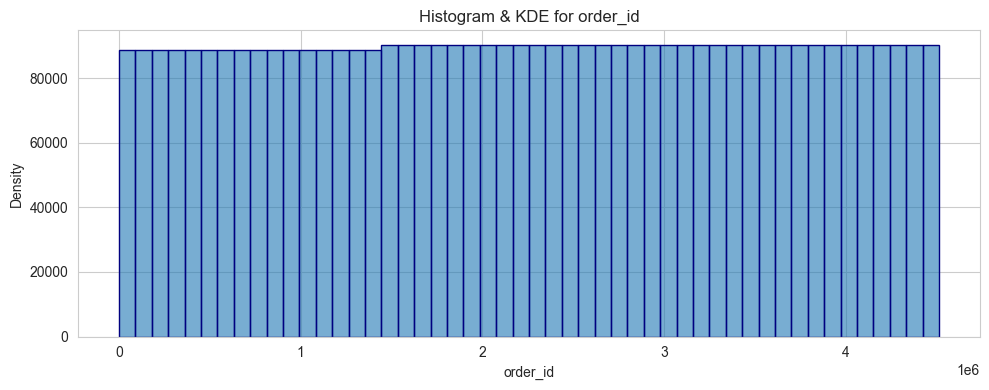


Descriptive statistics for order_id:
count    4.488810e+06
mean     2.266163e+06
std      1.301407e+06
min      0.000000e+00
25%      1.142607e+06
50%      2.270256e+06
75%      3.392458e+06
max      4.514660e+06
Name: order_id, dtype: float64


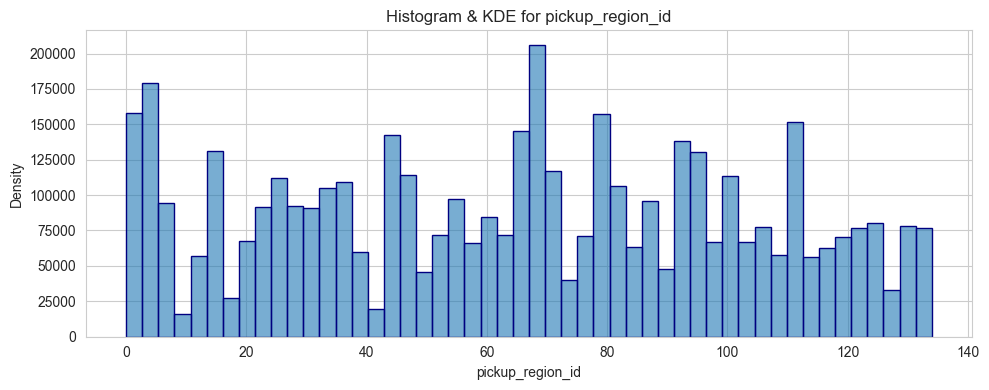


Descriptive statistics for pickup_region_id:
count    4.488810e+06
mean     6.457912e+01
std      3.791382e+01
min      0.000000e+00
25%      3.300000e+01
50%      6.600000e+01
75%      9.500000e+01
max      1.340000e+02
Name: pickup_region_id, dtype: float64


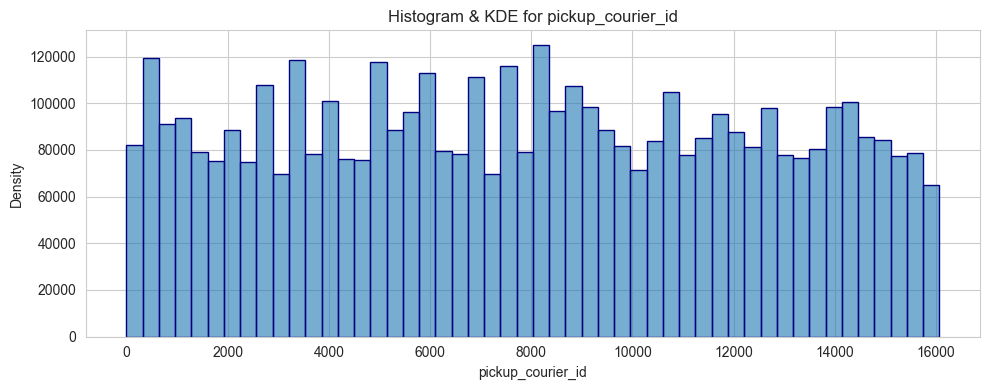


Descriptive statistics for pickup_courier_id:
count    4.488810e+06
mean     7.887326e+03
std      4.566228e+03
min      0.000000e+00
25%      4.035000e+03
50%      7.870000e+03
75%      1.175400e+04
max      1.606600e+04
Name: pickup_courier_id, dtype: float64


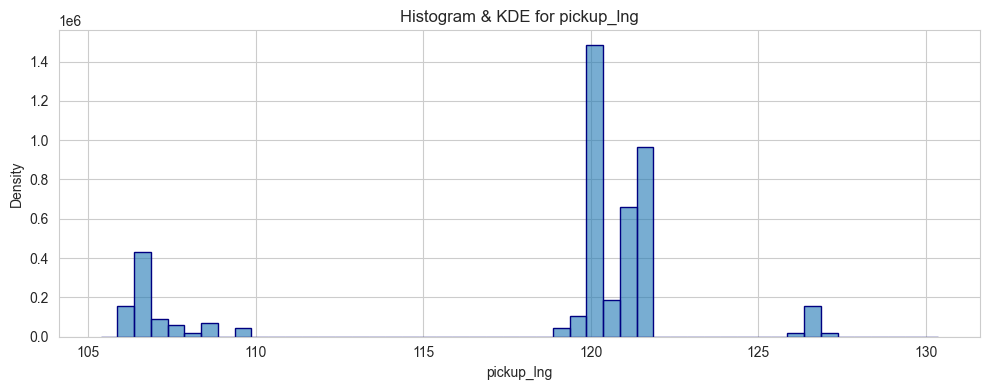


Descriptive statistics for pickup_lng:
count    4.488810e+06
mean     1.183502e+02
std      5.723463e+00
min      1.053727e+02
25%      1.199450e+02
50%      1.202760e+02
75%      1.213765e+02
max      1.303666e+02
Name: pickup_lng, dtype: float64


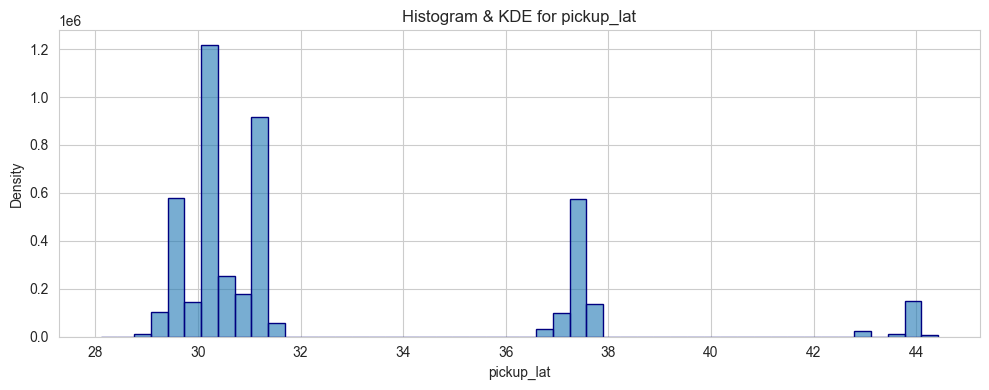


Descriptive statistics for pickup_lat:
count    4.488810e+06
mean     3.230939e+01
std      3.681836e+00
min      2.810210e+01
25%      3.019337e+01
50%      3.043530e+01
75%      3.135106e+01
max      4.442637e+01
Name: pickup_lat, dtype: float64


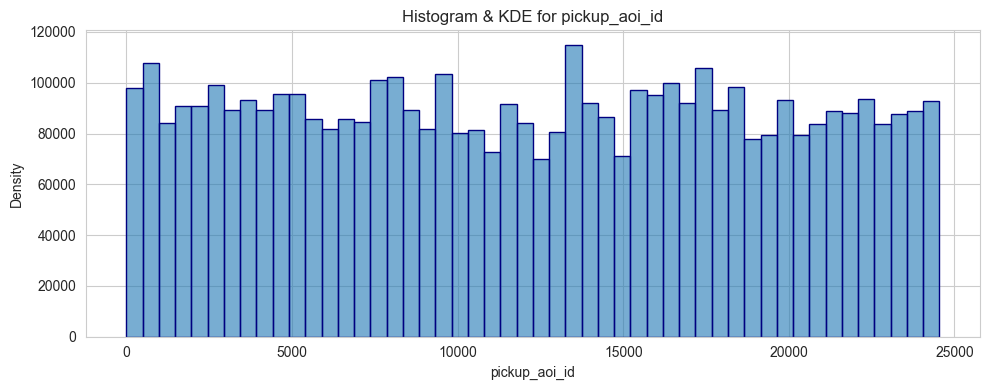


Descriptive statistics for pickup_aoi_id:
count    4.488810e+06
mean     1.215748e+04
std      7.130680e+03
min      0.000000e+00
25%      5.923000e+03
50%      1.217000e+04
75%      1.820100e+04
max      2.454300e+04
Name: pickup_aoi_id, dtype: float64


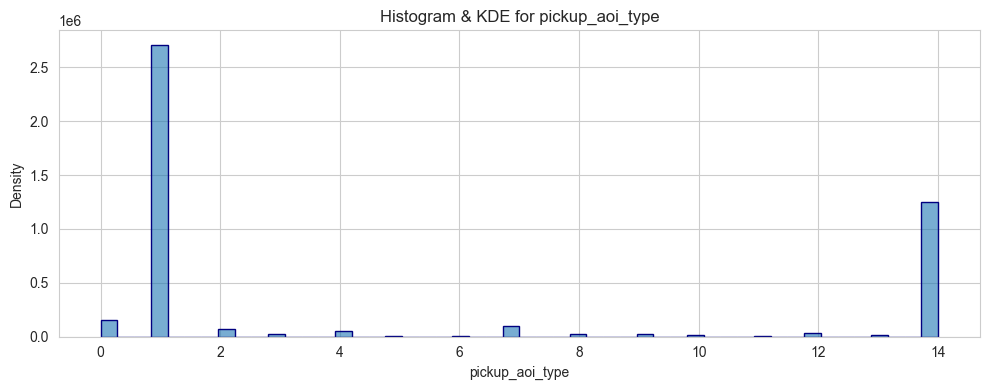


Descriptive statistics for pickup_aoi_type:
count    4.488810e+06
mean     5.043766e+00
std      5.848950e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.400000e+01
max      1.400000e+01
Name: pickup_aoi_type, dtype: float64


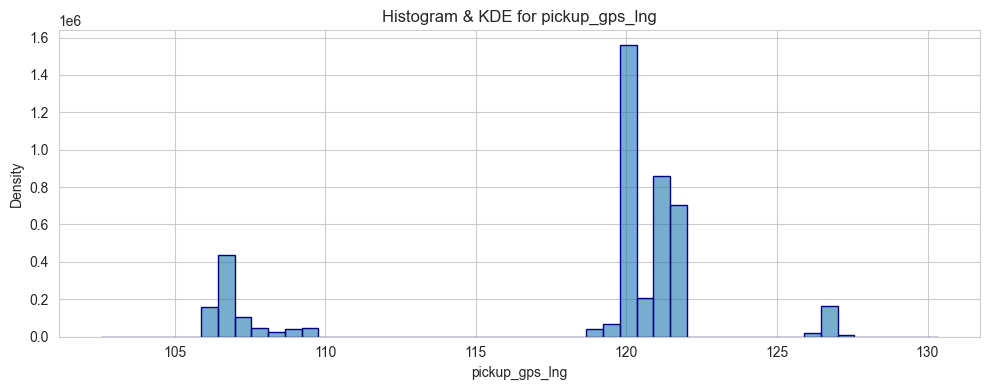


Descriptive statistics for pickup_gps_lng:
count    4.488810e+06
mean     1.183369e+02
std      5.717162e+00
min      1.025392e+02
25%      1.199451e+02
50%      1.202726e+02
75%      1.213764e+02
max      1.303508e+02
Name: pickup_gps_lng, dtype: float64


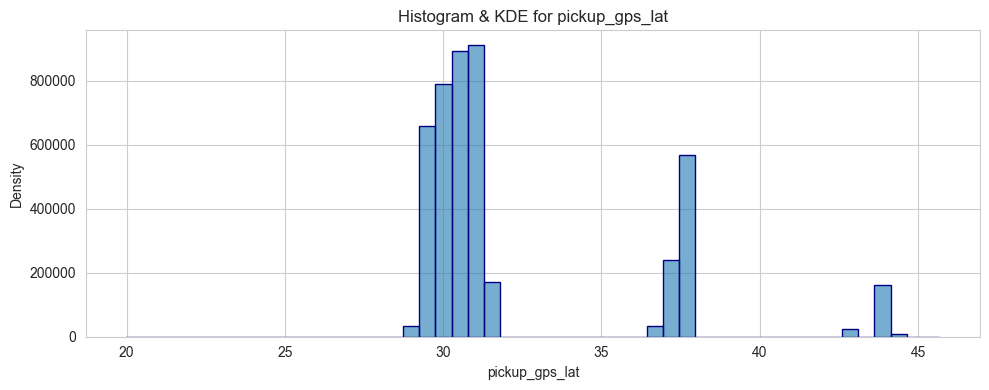


Descriptive statistics for pickup_gps_lat:
count    4.488810e+06
mean     3.230085e+01
std      3.684752e+00
min      1.999148e+01
25%      3.019363e+01
50%      3.043158e+01
75%      3.134226e+01
max      4.567432e+01
Name: pickup_gps_lat, dtype: float64


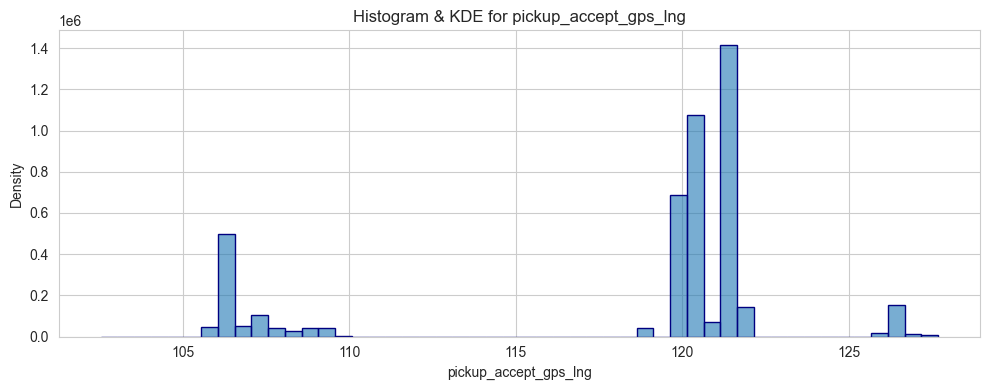


Descriptive statistics for pickup_accept_gps_lng:
count    4.488810e+06
mean     1.183391e+02
std      5.716956e+00
min      1.025391e+02
25%      1.199420e+02
50%      1.202782e+02
75%      1.213755e+02
max      1.276728e+02
Name: pickup_accept_gps_lng, dtype: float64


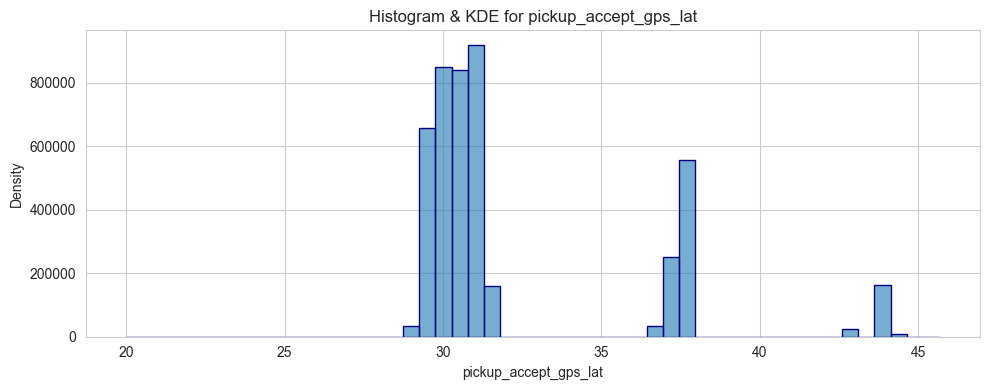


Descriptive statistics for pickup_accept_gps_lat:
count    4.488810e+06
mean     3.230161e+01
std      3.683288e+00
min      2.000799e+01
25%      3.019377e+01
50%      3.043286e+01
75%      3.134392e+01
max      4.567400e+01
Name: pickup_accept_gps_lat, dtype: float64


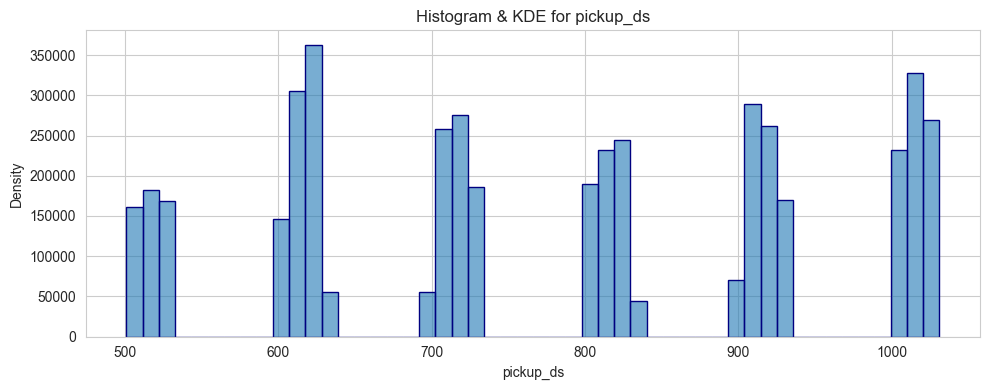


Descriptive statistics for pickup_ds:
count    4.488810e+06
mean     7.802934e+02
std      1.661300e+02
min      5.010000e+02
25%      6.220000e+02
50%      8.040000e+02
75%      9.200000e+02
max      1.031000e+03
Name: pickup_ds, dtype: float64


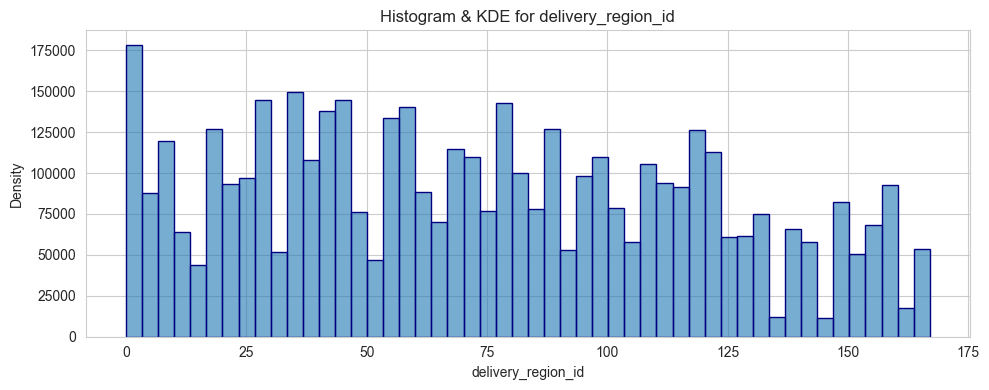


Descriptive statistics for delivery_region_id:
count    4.488810e+06
mean     7.381328e+01
std      4.538536e+01
min      0.000000e+00
25%      3.600000e+01
50%      7.100000e+01
75%      1.110000e+02
max      1.670000e+02
Name: delivery_region_id, dtype: float64


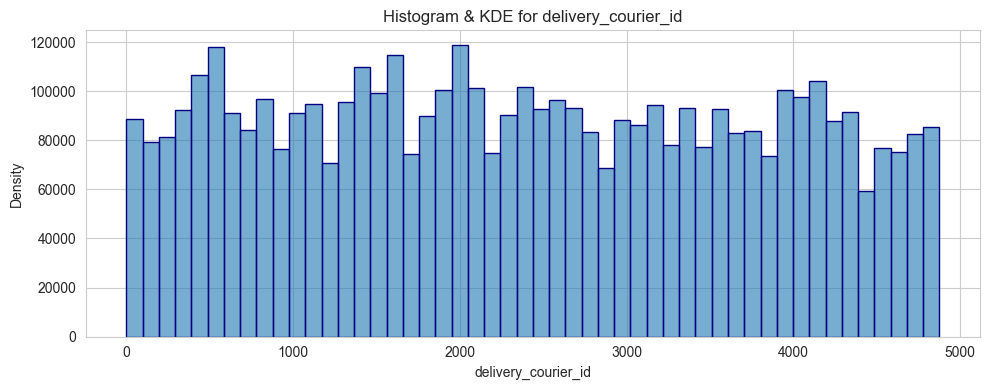


Descriptive statistics for delivery_courier_id:
count    4.488810e+06
mean     2.385289e+03
std      1.390541e+03
min      0.000000e+00
25%      1.206000e+03
50%      2.346000e+03
75%      3.588000e+03
max      4.876000e+03
Name: delivery_courier_id, dtype: float64


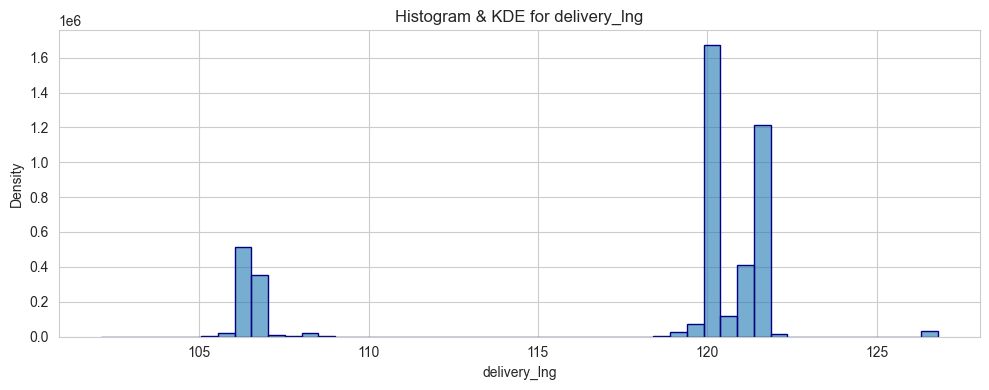


Descriptive statistics for delivery_lng:
count    4.488810e+06
mean     1.178688e+02
std      5.822301e+00
min      1.020849e+02
25%      1.199667e+02
50%      1.202321e+02
75%      1.214099e+02
max      1.268191e+02
Name: delivery_lng, dtype: float64


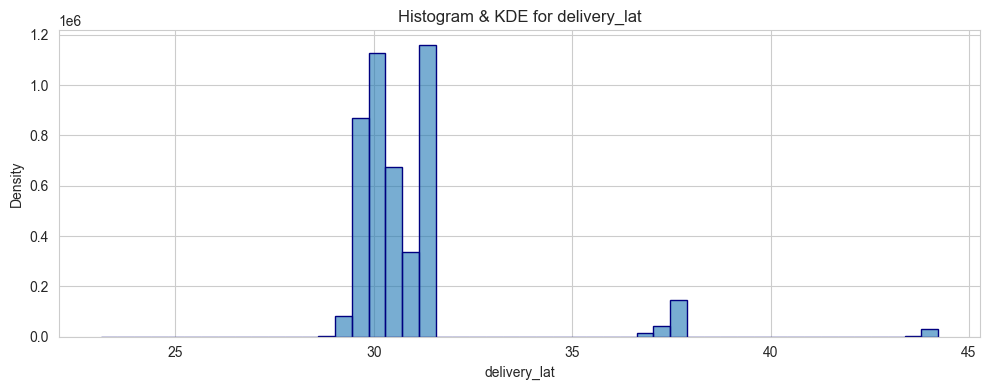


Descriptive statistics for delivery_lat:
count    4.488810e+06
mean     3.084851e+01
std      1.928059e+00
min      2.311348e+01
25%      3.012188e+01
50%      3.030657e+01
75%      3.118919e+01
max      4.422335e+01
Name: delivery_lat, dtype: float64


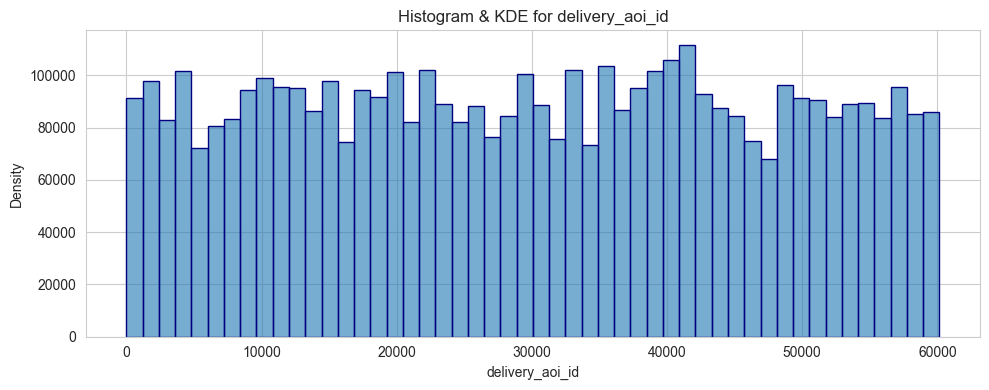


Descriptive statistics for delivery_aoi_id:
count    4.488810e+06
mean     2.998083e+04
std      1.729050e+04
min      0.000000e+00
25%      1.487400e+04
50%      3.005700e+04
75%      4.446400e+04
max      6.014900e+04
Name: delivery_aoi_id, dtype: float64


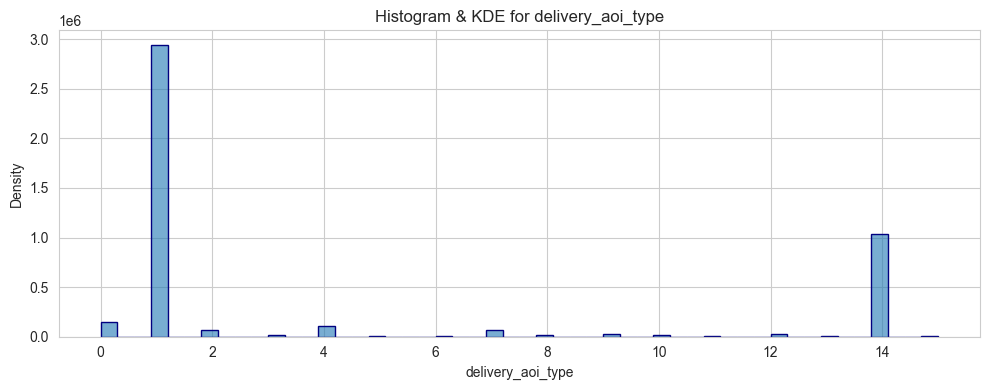


Descriptive statistics for delivery_aoi_type:
count    4.488810e+06
mean     4.355414e+00
std      5.527520e+00
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      8.000000e+00
max      1.500000e+01
Name: delivery_aoi_type, dtype: float64


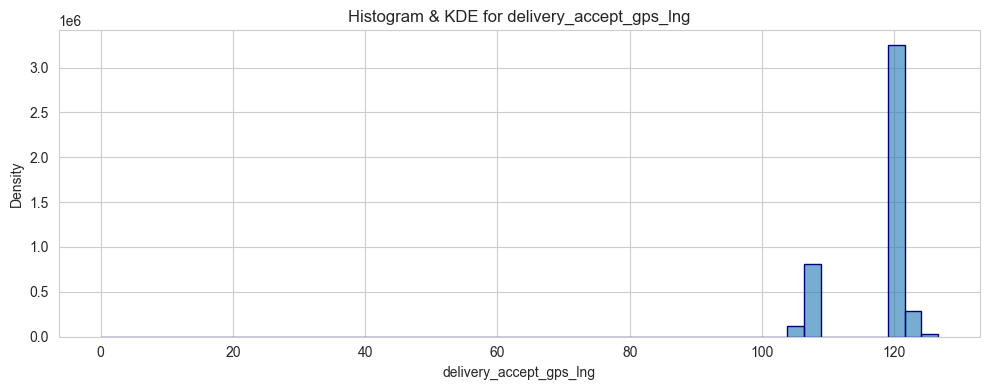


Descriptive statistics for delivery_accept_gps_lng:
count    4.488810e+06
mean     1.178664e+02
std      5.854448e+00
min     -9.000000e-05
25%      1.199621e+02
50%      1.202477e+02
75%      1.214002e+02
max      1.266289e+02
Name: delivery_accept_gps_lng, dtype: float64


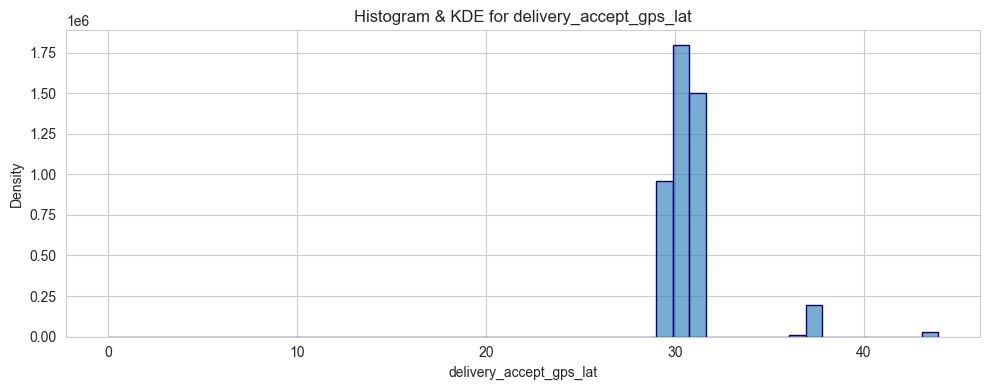


Descriptive statistics for delivery_accept_gps_lat:
count    4.488810e+06
mean     3.084424e+01
std      1.928699e+00
min     -9.000000e-05
25%      3.010518e+01
50%      3.031298e+01
75%      3.118779e+01
max      4.394521e+01
Name: delivery_accept_gps_lat, dtype: float64


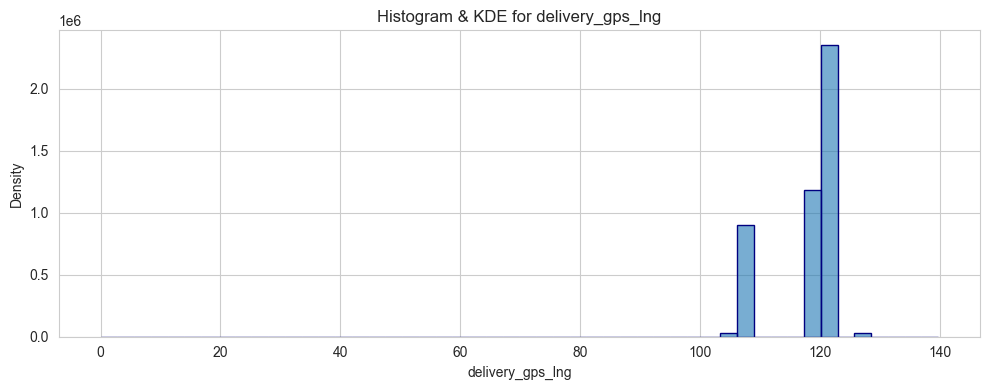


Descriptive statistics for delivery_gps_lng:
count    4.488810e+06
mean     1.178639e+02
std      5.867061e+00
min     -9.000000e-05
25%      1.199666e+02
50%      1.202318e+02
75%      1.214099e+02
max      1.397561e+02
Name: delivery_gps_lng, dtype: float64


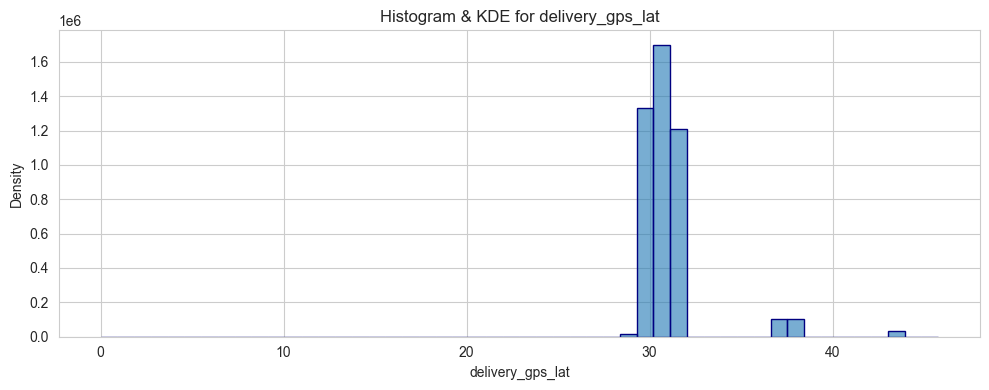


Descriptive statistics for delivery_gps_lat:
count    4.488810e+06
mean     3.084734e+01
std      1.937207e+00
min     -9.000000e-05
25%      3.012176e+01
50%      3.030688e+01
75%      3.118906e+01
max      4.576194e+01
Name: delivery_gps_lat, dtype: float64


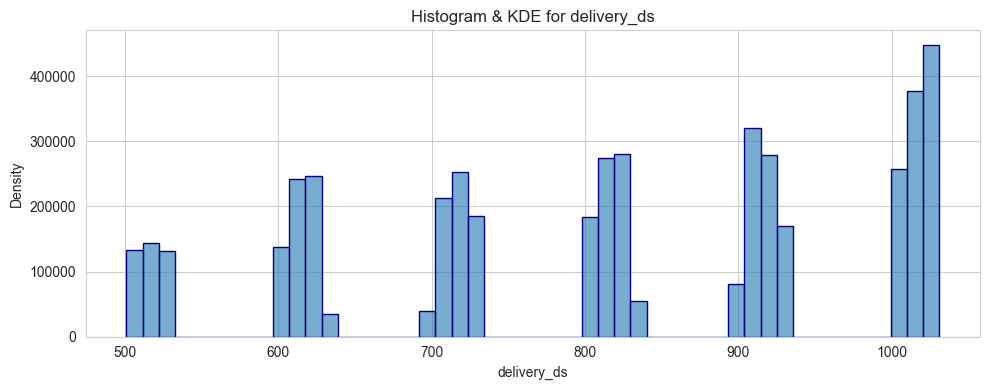


Descriptive statistics for delivery_ds:
count    4.488810e+06
mean     8.112397e+02
std      1.653612e+02
min      5.010000e+02
25%      7.030000e+02
50%      8.200000e+02
75%      9.290000e+02
max      1.031000e+03
Name: delivery_ds, dtype: float64


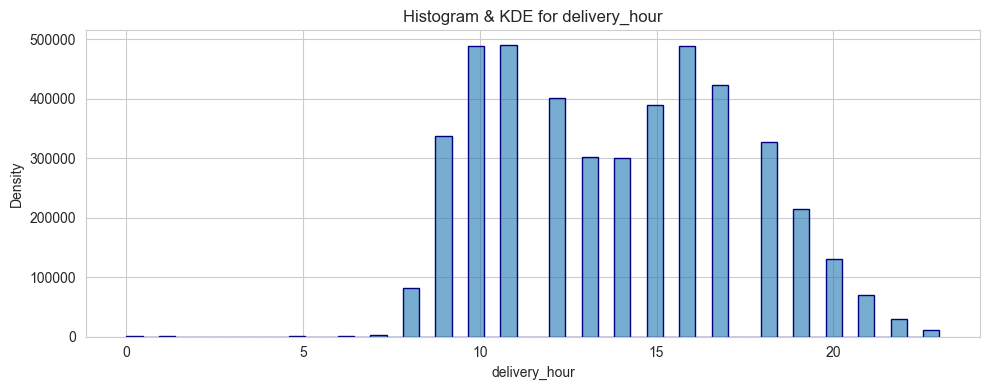


Descriptive statistics for delivery_hour:
count    4.488810e+06
mean     1.397040e+01
std      3.455020e+00
min      0.000000e+00
25%      1.100000e+01
50%      1.400000e+01
75%      1.700000e+01
max      2.300000e+01
Name: delivery_hour, dtype: float64


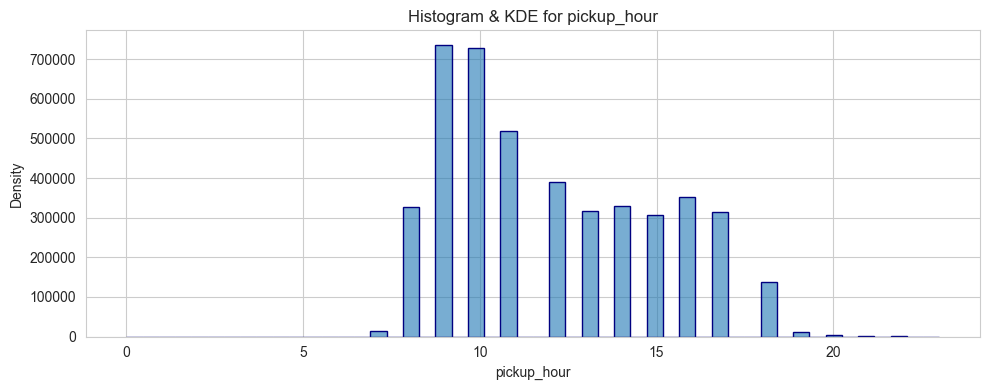


Descriptive statistics for pickup_hour:
count    4.488810e+06
mean     1.205734e+01
std      2.961246e+00
min      0.000000e+00
25%      1.000000e+01
50%      1.100000e+01
75%      1.500000e+01
max      2.300000e+01
Name: pickup_hour, dtype: float64


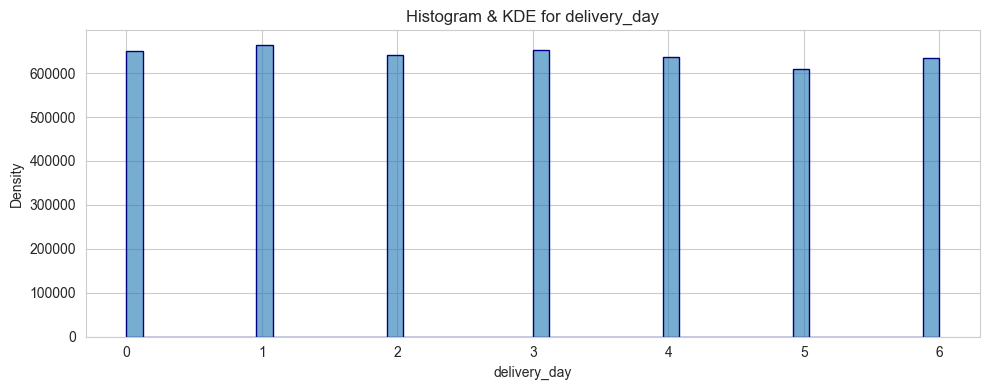


Descriptive statistics for delivery_day:
count    4.488810e+06
mean     2.963794e+00
std      1.998470e+00
min      0.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      5.000000e+00
max      6.000000e+00
Name: delivery_day, dtype: float64


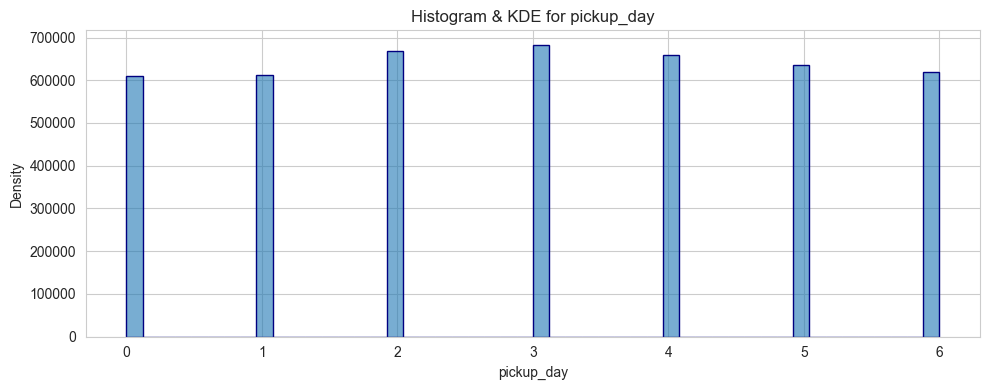


Descriptive statistics for pickup_day:
count    4.488810e+06
mean     3.015862e+00
std      1.967652e+00
min      0.000000e+00
25%      1.000000e+00
50%      3.000000e+00
75%      5.000000e+00
max      6.000000e+00
Name: pickup_day, dtype: float64


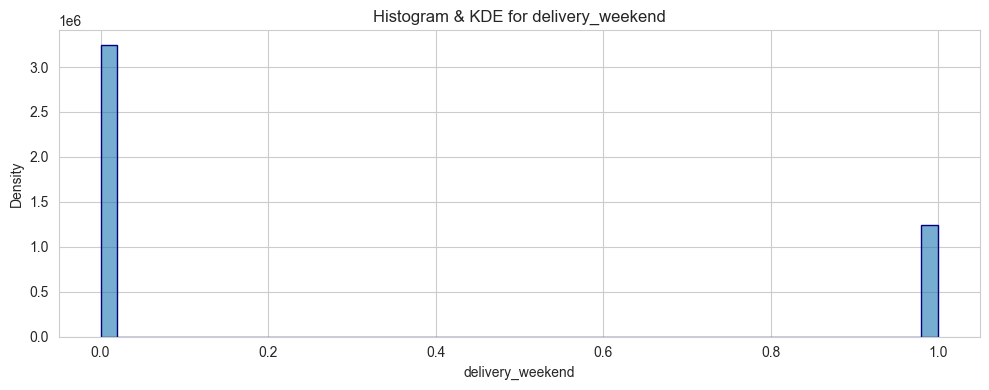


Descriptive statistics for delivery_weekend:
count    4.488810e+06
mean     2.770458e-01
std      4.475394e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: delivery_weekend, dtype: float64


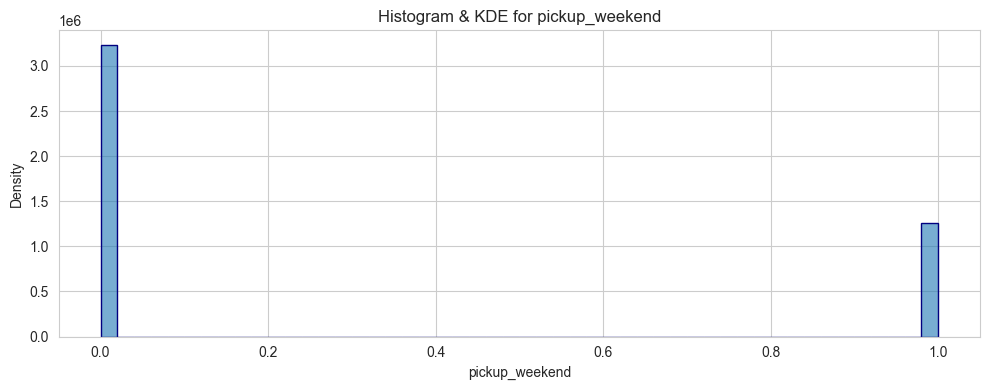


Descriptive statistics for pickup_weekend:
count    4.488810e+06
mean     2.798492e-01
std      4.489250e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.000000e+00
Name: pickup_weekend, dtype: float64


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

for col in dataset.select_dtypes(include=['int', 'float']).columns:
    plt.figure(figsize=(10, 4))
    sns.histplot(data=dataset, x=col, bins=50, alpha=0.6, edgecolor='navy', linewidth=1)
    plt.title(f'Histogram & KDE for {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.tight_layout()
    plt.show()

    print(f'\nDescriptive statistics for {col}:')
    print(dataset[col].describe().T)


- pickup_hour : Bimodal, right skew with most active hour being 9 in the morning.
- delivery_hour : Bimodal with peak hours being 10, 11 and 16.
- pickup_day : Mostly picked on Thursday.
- delivery_day : Mostly delivered up on Tuesday.
- pickup_weekend : Mostly picked on Weekdays, almost thrice.
- deliver_weekend : Mostly delivered on Weekdays, alsmost thrice.
- pickup_lat : Hast three Clusters
- pickup_lng : Hast three Clusters
- delivery_lat : Hast two Clusters
- delivery_lng : Hast two Clusters

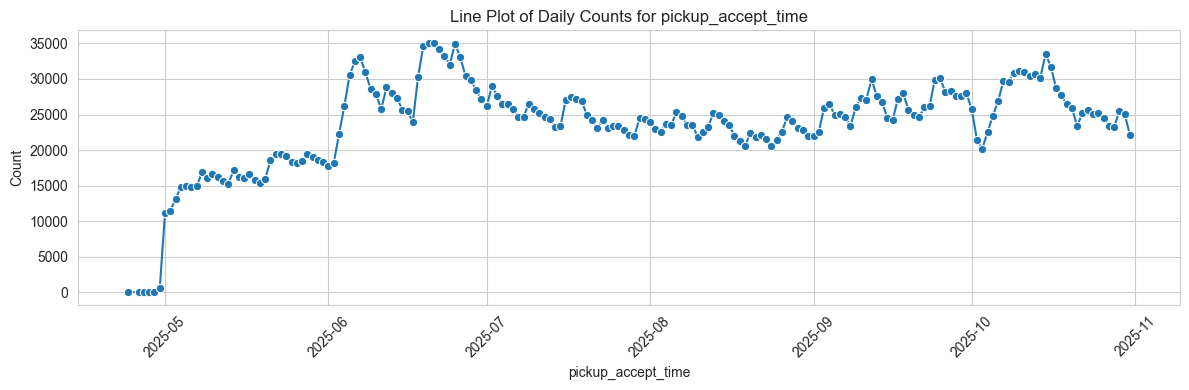


Descriptive statistics for pickup_accept_time:
count                          4488810
mean     2025-08-05 10:10:09.145849600
min                2025-04-24 08:18:00
25%                2025-06-22 09:29:00
50%                2025-08-04 10:49:00
75%                2025-09-20 07:58:00
max                2025-10-31 19:05:00
Name: pickup_accept_time, dtype: object


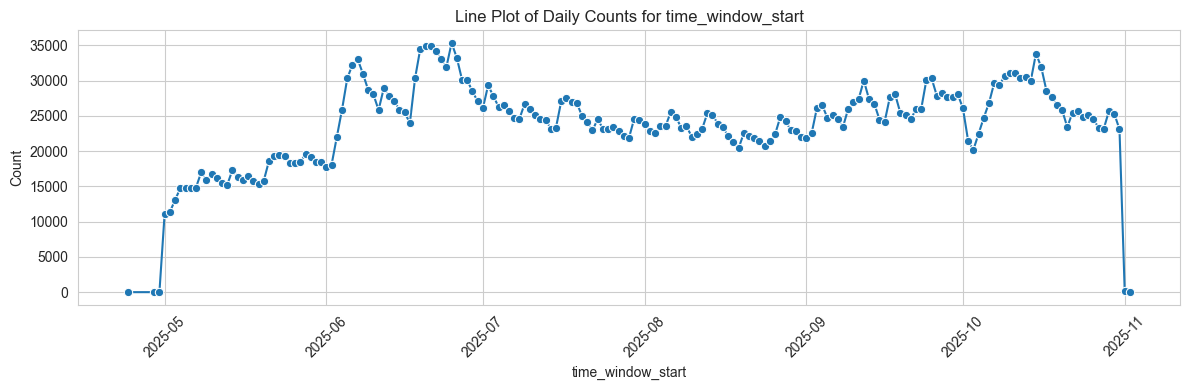


Descriptive statistics for time_window_start:
count                          4488810
mean     2025-08-05 13:28:00.757670400
min                2025-04-24 09:00:00
25%                2025-06-22 13:00:00
50%                2025-08-04 15:00:00
75%                2025-09-20 09:00:00
max                2025-11-02 17:00:00
Name: time_window_start, dtype: object


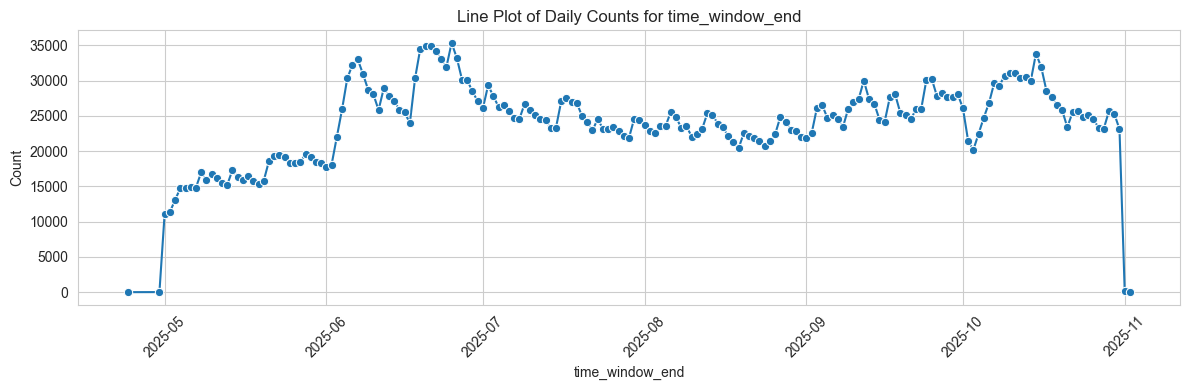


Descriptive statistics for time_window_end:
count                          4488810
mean     2025-08-05 15:35:58.824117248
min                2025-04-24 23:59:00
25%                2025-06-22 15:00:00
50%                2025-08-04 17:00:00
75%                2025-09-20 11:00:00
max                2025-11-02 19:00:00
Name: time_window_end, dtype: object


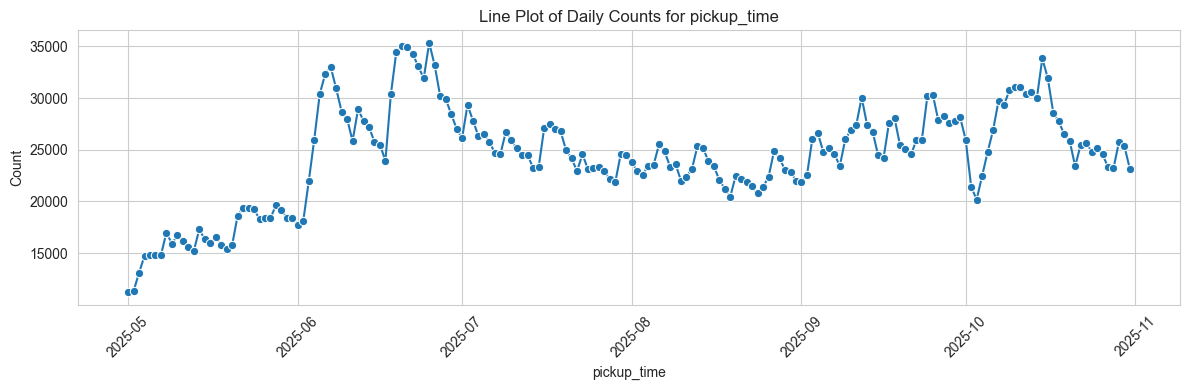


Descriptive statistics for pickup_time:
count                          4488810
mean     2025-08-05 13:51:33.575649536
min                2025-05-01 07:32:00
25%                2025-06-22 14:21:00
50%                2025-08-04 15:11:00
75%                2025-09-20 10:21:00
max                2025-10-31 23:01:00
Name: pickup_time, dtype: object


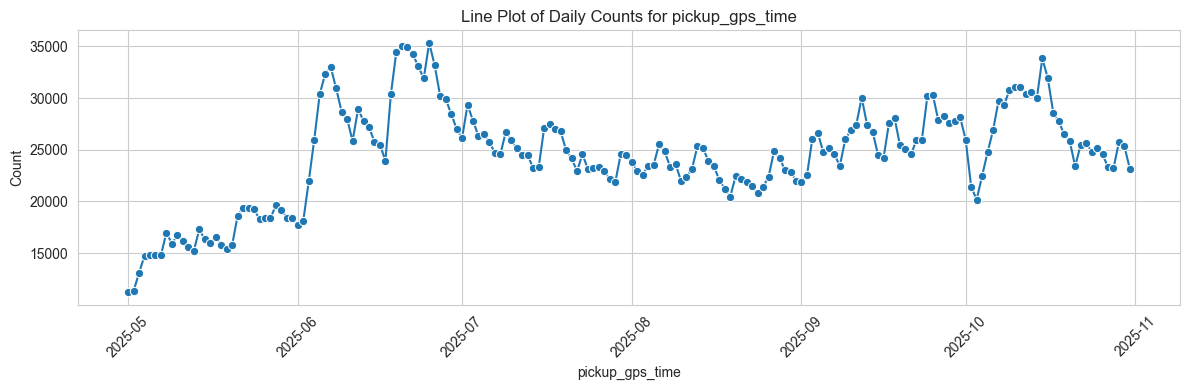


Descriptive statistics for pickup_gps_time:
count                          4488810
mean     2025-08-05 13:51:15.246355968
min                2025-05-01 07:32:00
25%                2025-06-22 14:21:00
50%                2025-08-04 15:11:00
75%                2025-09-20 10:20:42
max                2025-10-31 23:00:42
Name: pickup_gps_time, dtype: object


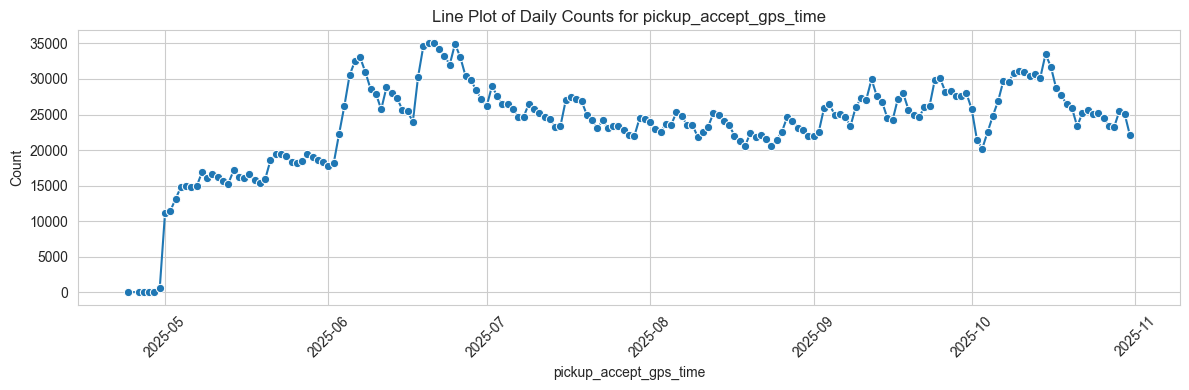


Descriptive statistics for pickup_accept_gps_time:
count                          4488810
mean     2025-08-05 10:09:13.927441920
min                2025-04-24 08:17:05
25%                2025-06-22 09:29:00
50%                2025-08-04 10:48:05
75%                2025-09-20 07:57:05
max                2025-10-31 19:04:05
Name: pickup_accept_gps_time, dtype: object


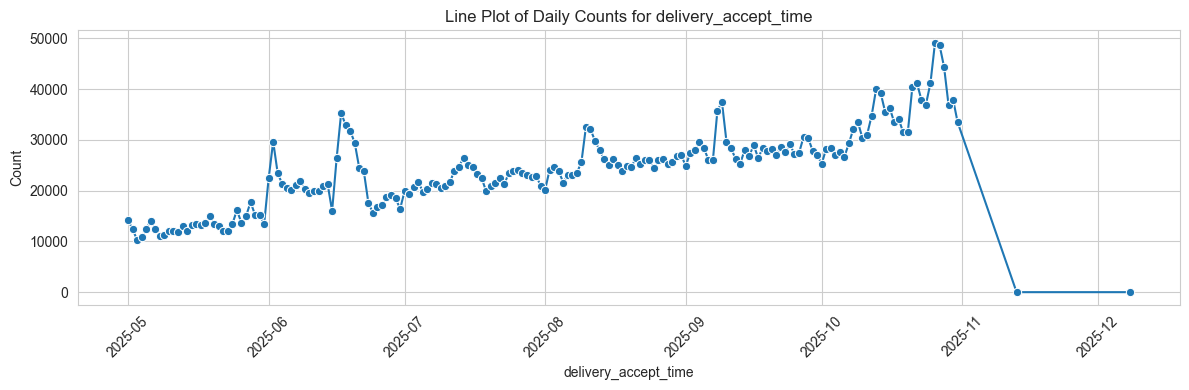


Descriptive statistics for delivery_accept_time:
count                          4488810
mean     2025-08-15 03:49:12.039617792
min                2025-05-01 06:11:00
25%                2025-07-03 12:11:00
50%                2025-08-20 07:24:00
75%                2025-09-29 12:58:00
max                2025-12-08 12:10:00
Name: delivery_accept_time, dtype: object


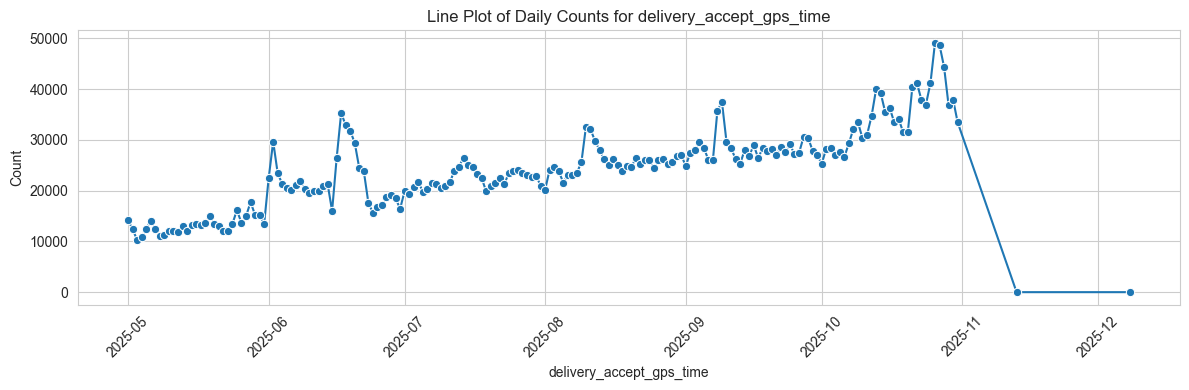


Descriptive statistics for delivery_accept_gps_time:
count                          4488810
mean     2025-08-15 03:49:12.039617792
min                2025-05-01 06:11:00
25%                2025-07-03 12:11:00
50%                2025-08-20 07:24:00
75%                2025-09-29 12:58:00
max                2025-12-08 12:10:00
Name: delivery_accept_gps_time, dtype: object


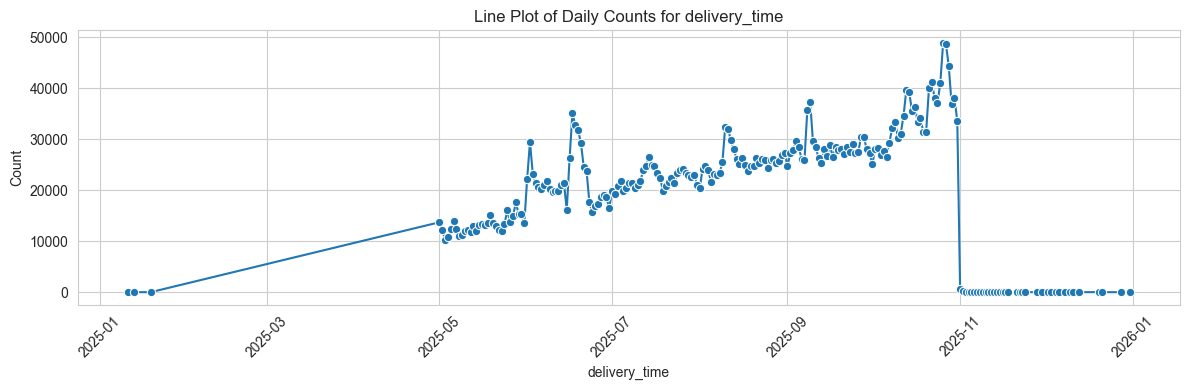


Descriptive statistics for delivery_time:
count                          4488810
mean     2025-08-15 06:55:03.328369664
min                2025-01-11 19:20:00
25%                2025-07-03 15:08:00
50%                2025-08-20 09:10:00
75%                2025-09-29 15:43:00
max                2025-12-31 21:03:00
Name: delivery_time, dtype: object


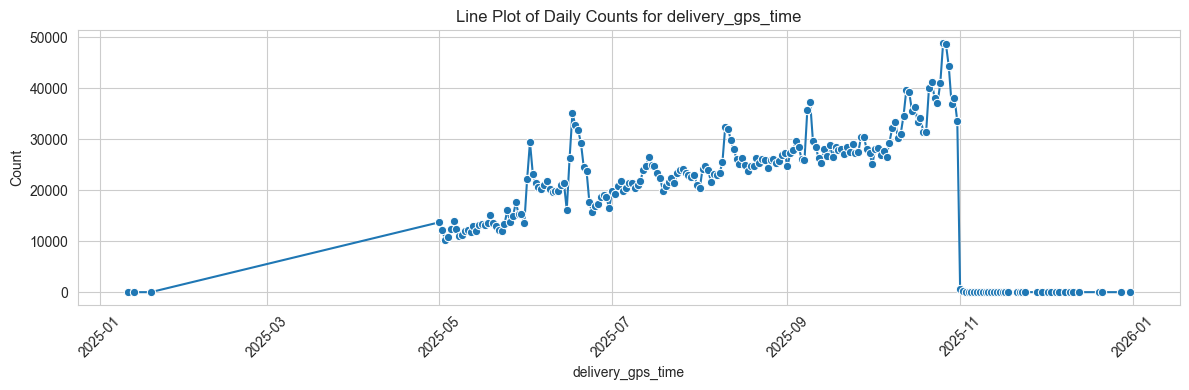


Descriptive statistics for delivery_gps_time:
count                          4488810
mean     2025-08-15 06:55:03.328369664
min                2025-01-11 19:20:00
25%                2025-07-03 15:08:00
50%                2025-08-20 09:10:00
75%                2025-09-29 15:43:00
max                2025-12-31 21:03:00
Name: delivery_gps_time, dtype: object


In [ ]:
sns.set_style("whitegrid")

for col in dataset.select_dtypes(include=['datetime64[ns]']).columns:
    daily_counts = ( dataset[col].dt.floor('D').value_counts().sort_index())

    plt.figure(figsize=(12, 4))
    sns.lineplot(x=daily_counts.index, y=daily_counts.values, marker='o')
    plt.title(f'Line Plot of Daily Counts for {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    print(f'\nDescriptive statistics for {col}:')
    print(dataset[col].describe())

- pickup_accept_time, time_window_start, time_window_end, pickup_time, pickup_gps_time, pickup_gps_time, pickup_accept_gps_time : peaks around end of june and min october
- delivery_accept_time, delivery_accept_gps_time : gradually increases and suddenly drops around november
- delivery_time, delivery_gps_time : suddenly increases from may, gradually increases and suddenly drops around november

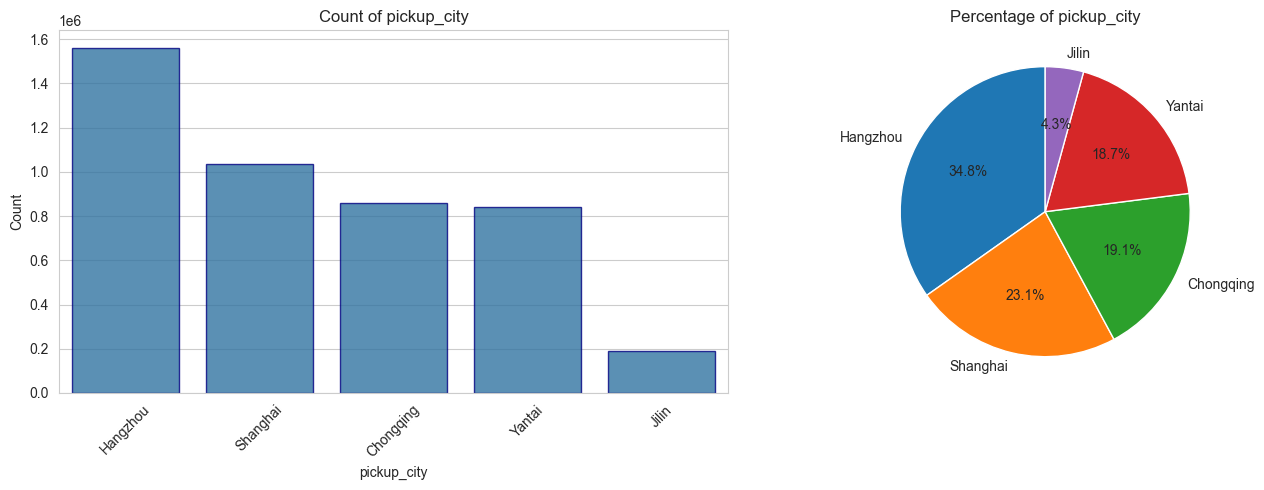

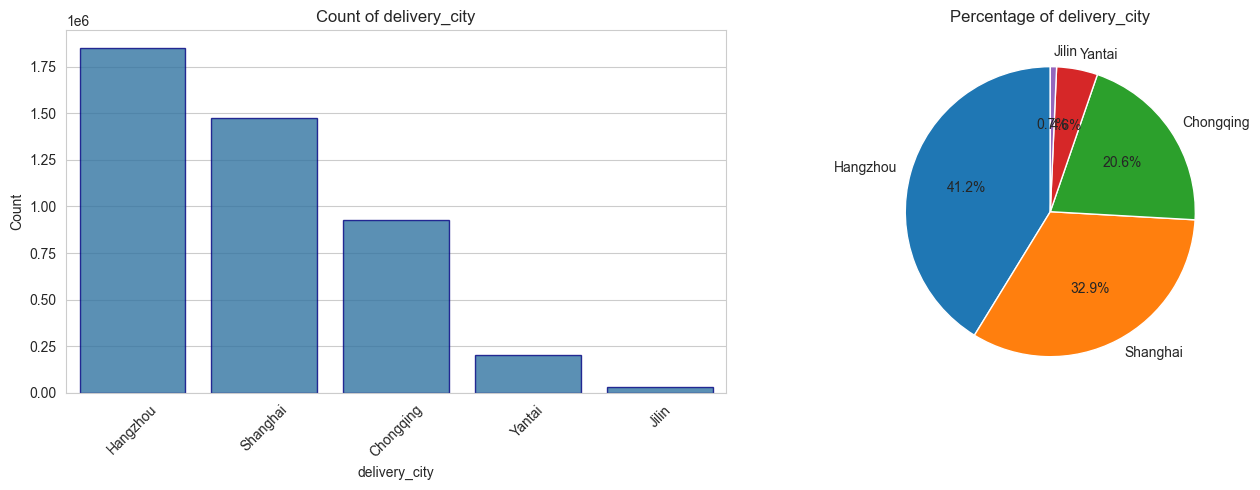

In [ ]:
sns.set_style("whitegrid")

for col in dataset.select_dtypes(include=['object']).columns:
    counts = dataset[col].value_counts(dropna=False)
    perc   = dataset[col].value_counts(dropna=False, normalize=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    sns.barplot(x=counts.index, y=counts.values, ax=axes[0], edgecolor='navy', linewidth=1, alpha=0.8)
    axes[0].set_title(f'Count of {col}')
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Count')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].pie(perc.values, labels=perc.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 10})
    axes[1].set_title(f'Percentage of {col}')

    plt.tight_layout()
    plt.show()


Very concentrated in Hangzhou and Shanghai together over two-thirds of all orders, with Hangzhou especially dominant on the delivery side and Jilin barely registering.

#### ***BiVariate Analysis***

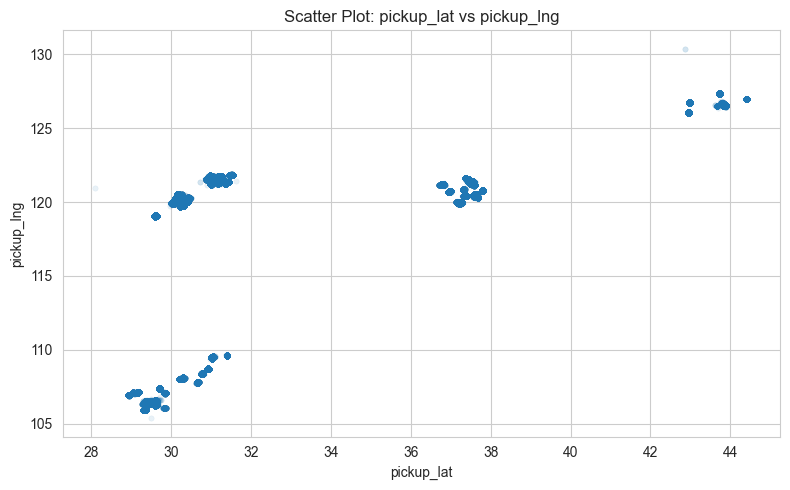

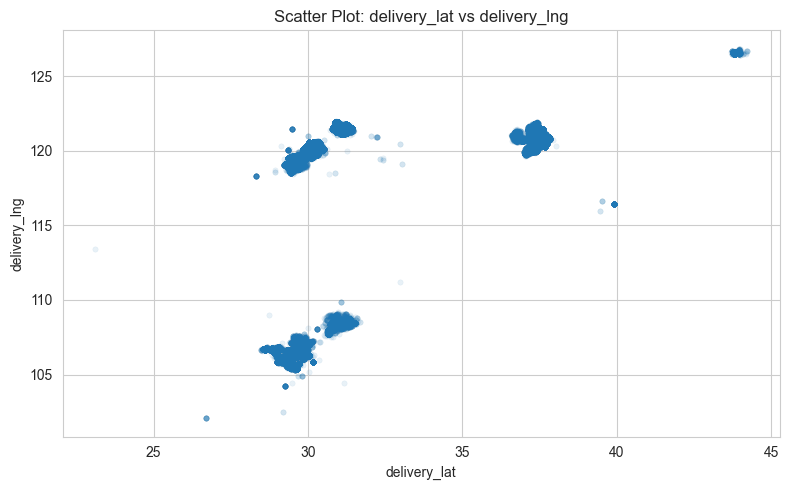

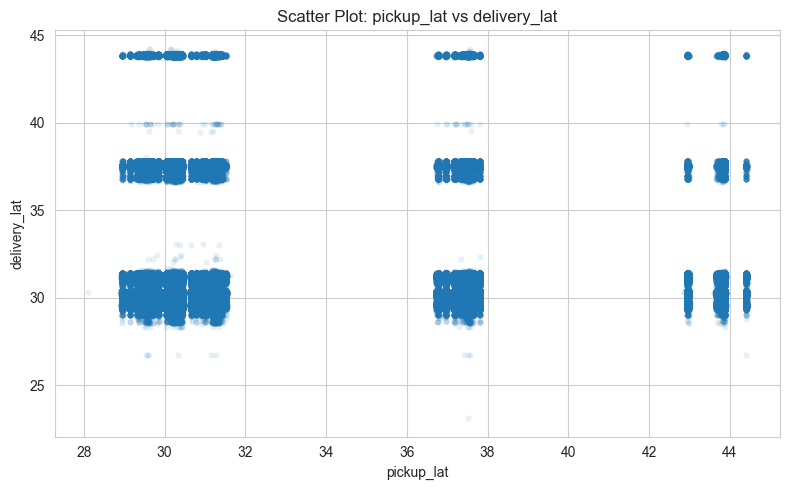

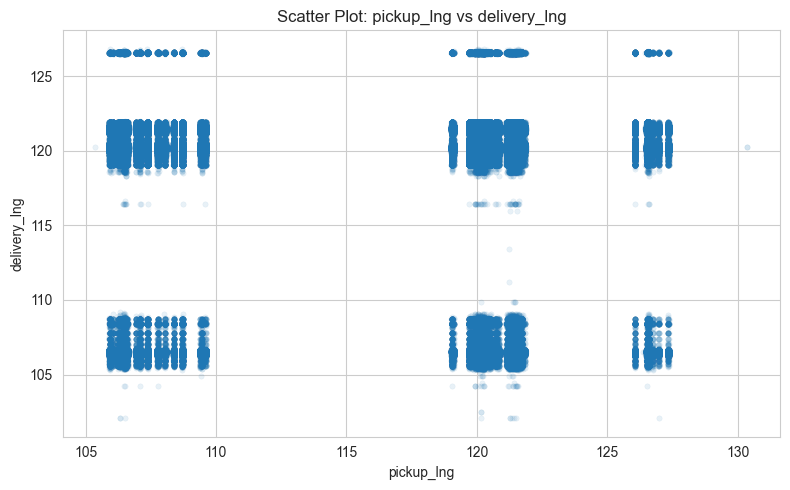

In [ ]:
pairs = {
    'pickup_lat vs pickup_lng': ['pickup_lat', 'pickup_lng'],
    'delivery_lat vs delivery_lng': ['delivery_lat', 'delivery_lng'],
    'pickup_lat vs delivery_lat': ['pickup_lat', 'delivery_lat'],
    'pickup_lng vs delivery_lng': ['pickup_lng', 'delivery_lng'],
}

sns.set_style('whitegrid')

for title, [x_col, y_col] in pairs.items():
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=dataset, x=x_col, y=y_col, alpha=0.1, edgecolor=None, s=15)
    plt.title(f'Scatter Plot: {x_col} vs {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()

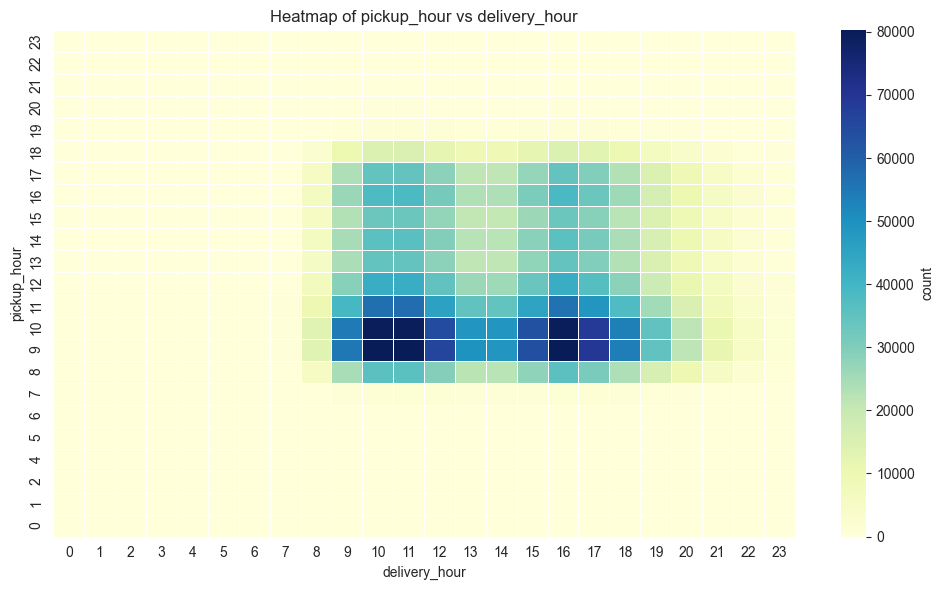

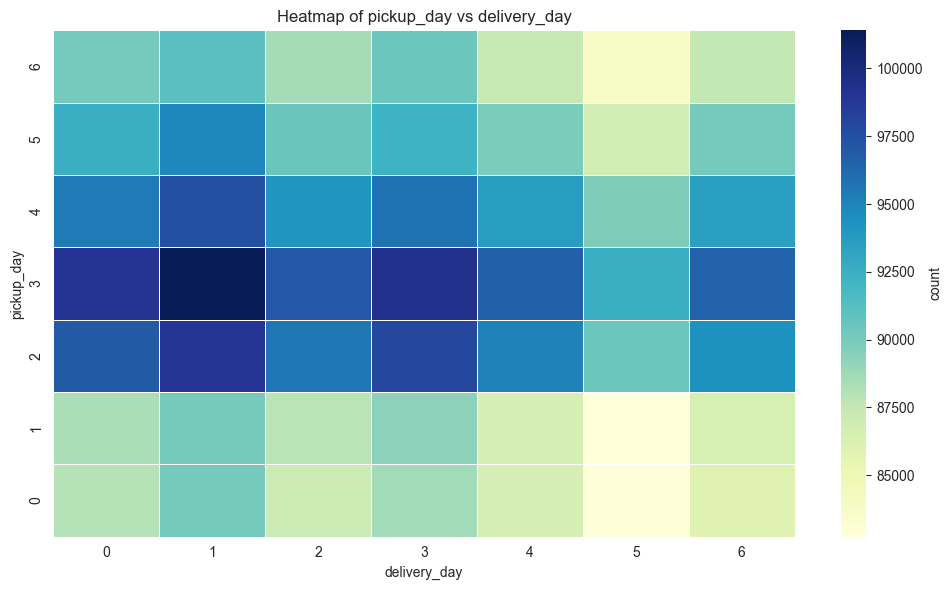

In [ ]:
pairs = {
    'pickup_hour vs delivery_hour': ['pickup_hour', 'delivery_hour'],
    'pickup_day vs delivery_day': ['pickup_day', 'delivery_day']
}

for title, [x_col, y_col] in pairs.items():
    heat_data = ( dataset.groupby([x_col, y_col]).size().unstack(fill_value=0))
    heat_data = heat_data.sort_index(axis=0, ascending=False)
    heat_data = heat_data.sort_index(axis=1)
    plt.figure(figsize=(10, 6))
    sns.heatmap( heat_data, cmap="YlGnBu", linewidths=0.5, cbar_kws={'label': 'count'})
    plt.title(f'Heatmap of {x_col} vs {y_col}')
    plt.xlabel(y_col)
    plt.ylabel(x_col)
    plt.tight_layout()
    plt.show()


- The heatmap shows that most pickups occur between 9 AM and 11 AM, and their deliveries are typically completed between
10 AM and 5 PM, indicating a strong concentration of same-day deliveries within business hours.
- The heatmap reveals that most pickups and deliveries occur midweek (especially on Wednesdays and Thursdays, i.e., days 2-4), with a noticeable dip in delivery activity over the weekend (days 5-6), suggesting lower logistics volume toward the week's end

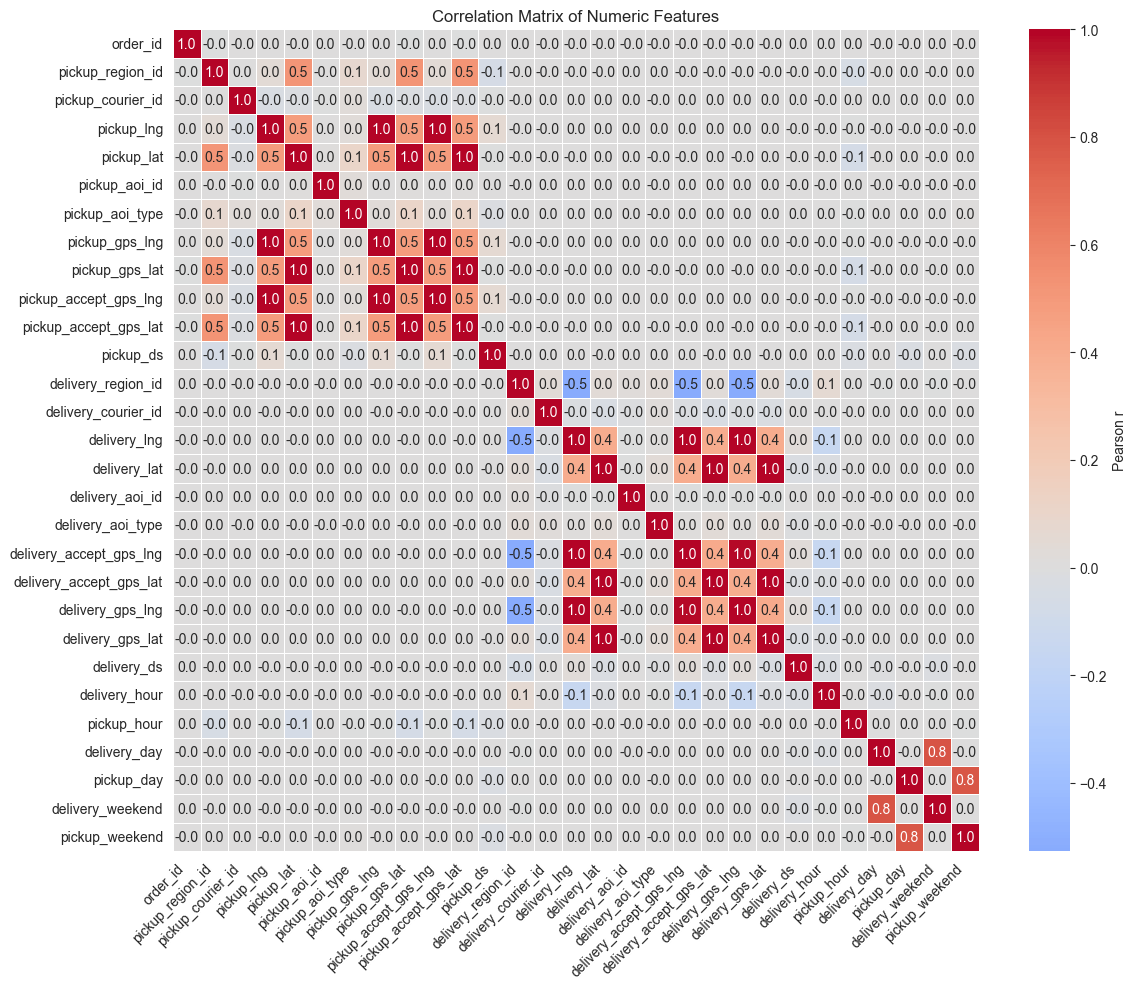

In [ ]:
corr = dataset[dataset.select_dtypes(include=['int', 'float']).columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap( corr, annot=True, fmt=".1f",  cmap="coolwarm", center=0, linewidths=0.5, cbar_kws={'label': 'Pearson r'})
plt.title("Correlation Matrix of Numeric Features")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Perfect Correlations
- Lat with their GPS Lat [Positive]
- Lng with their GPS Lng [Positive]

Strong Correlations
- delivery_weekend and delivery_day, pickup_weekend and pickup_day [positive]

Moderate Correlations
- pickup_region_id with pickup_lat, pickup_gps_lat, pickup_accept_gps_lat [positive]
- delivery_region_id with delivery_lat, delivery_gps_lat, delivery_accept_gps_lat [negative]
- pickup_lng, pickup_lat, pickup_gps_lat, pickup_accept_gps_lat with eachother [positive]
- pickup_lat, pickup_lng, pickup_gps_lng, pickup_accept_gps_lng with eachother [positive]
- delivery_lng, delivery_lat, delivery_gps_lat, delivery_accept_gps_lat with eachother [positive]
- delivery_lat, delivery_lng, delivery_gps_lng, delivery_accept_gps_lng with eachother [positive]

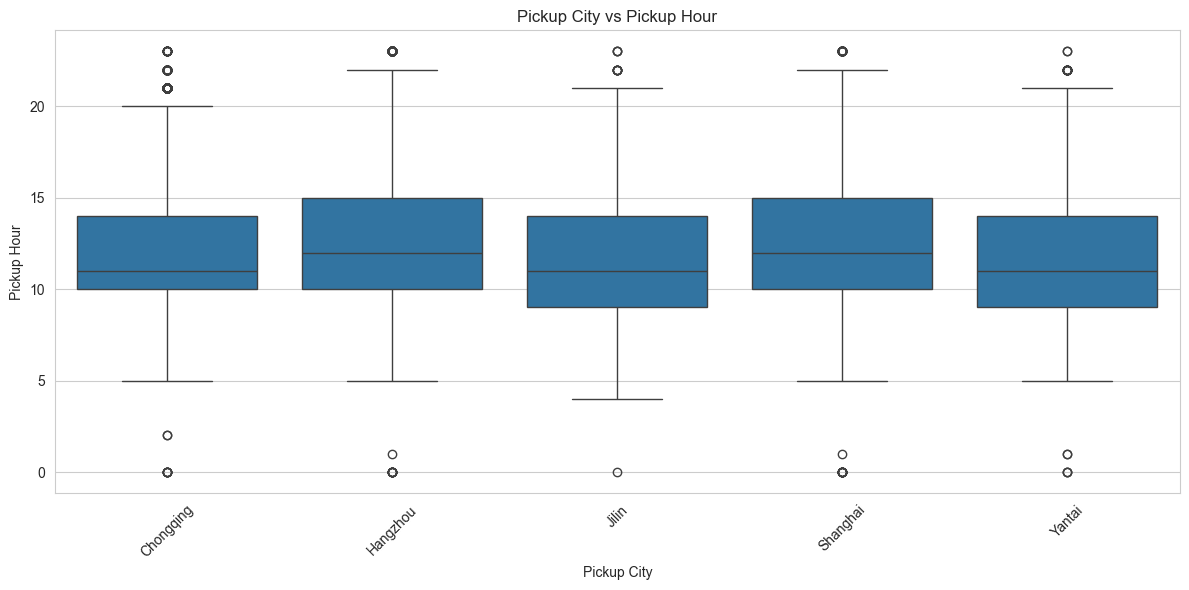

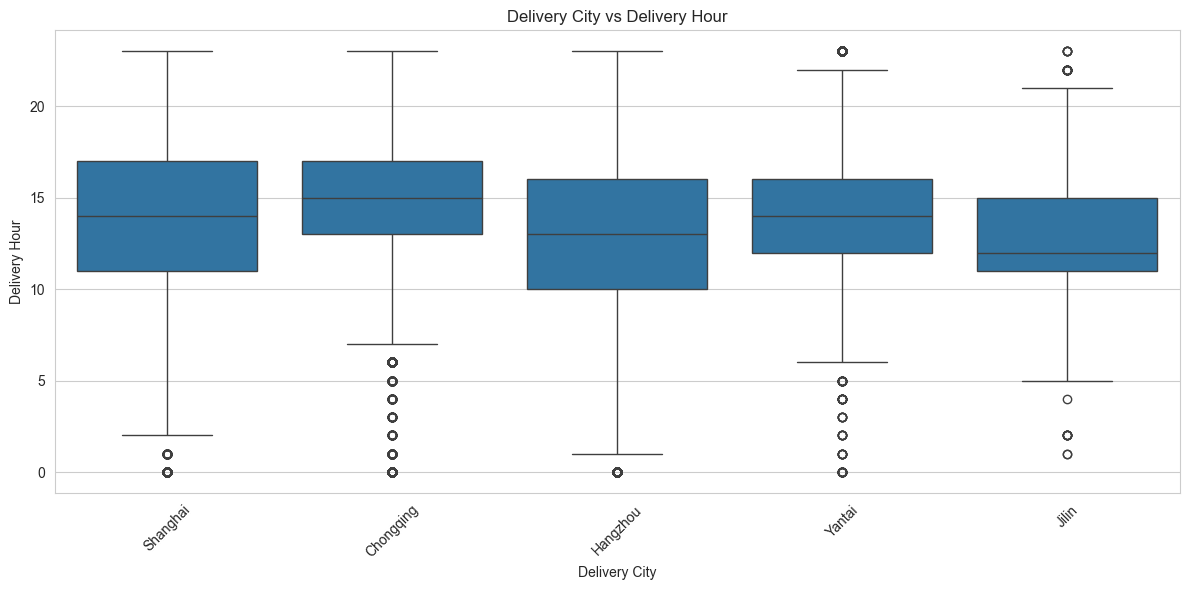

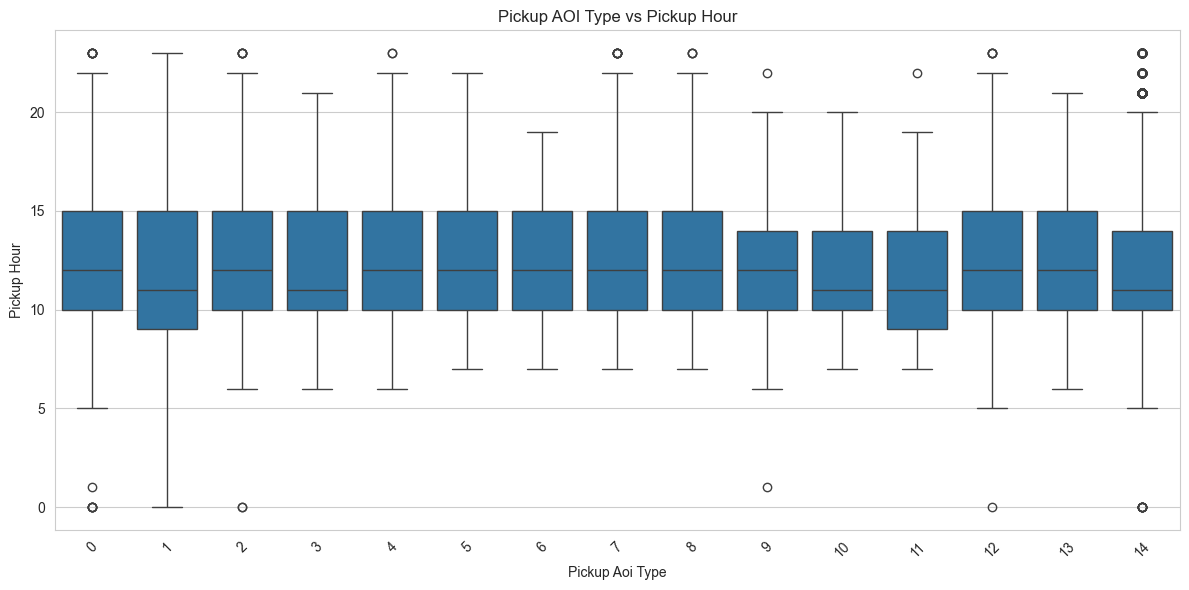

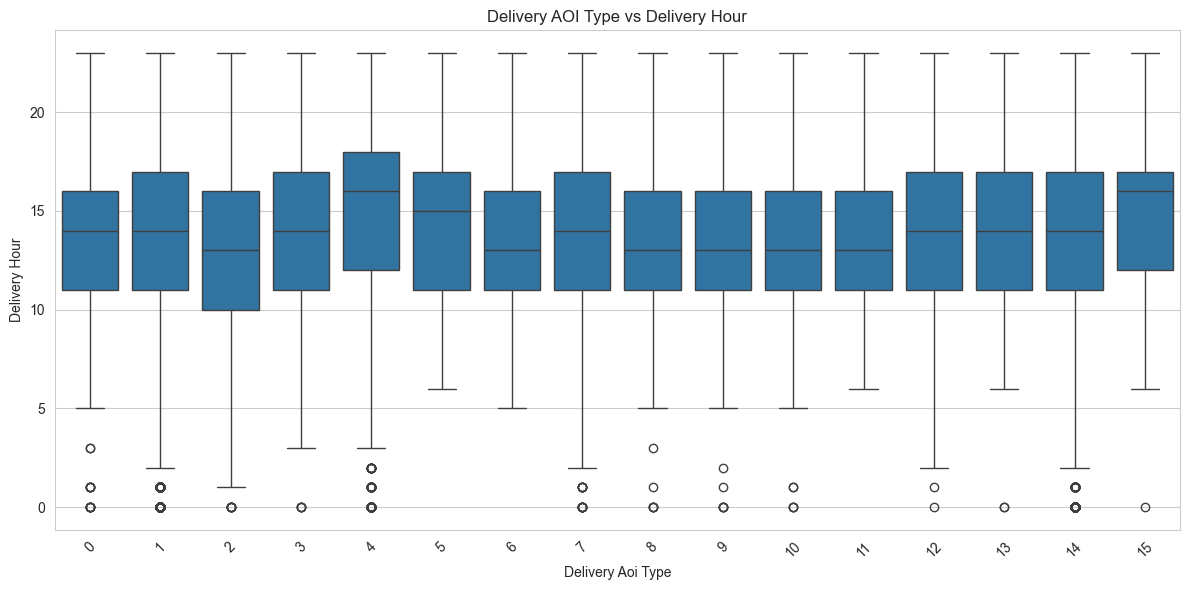

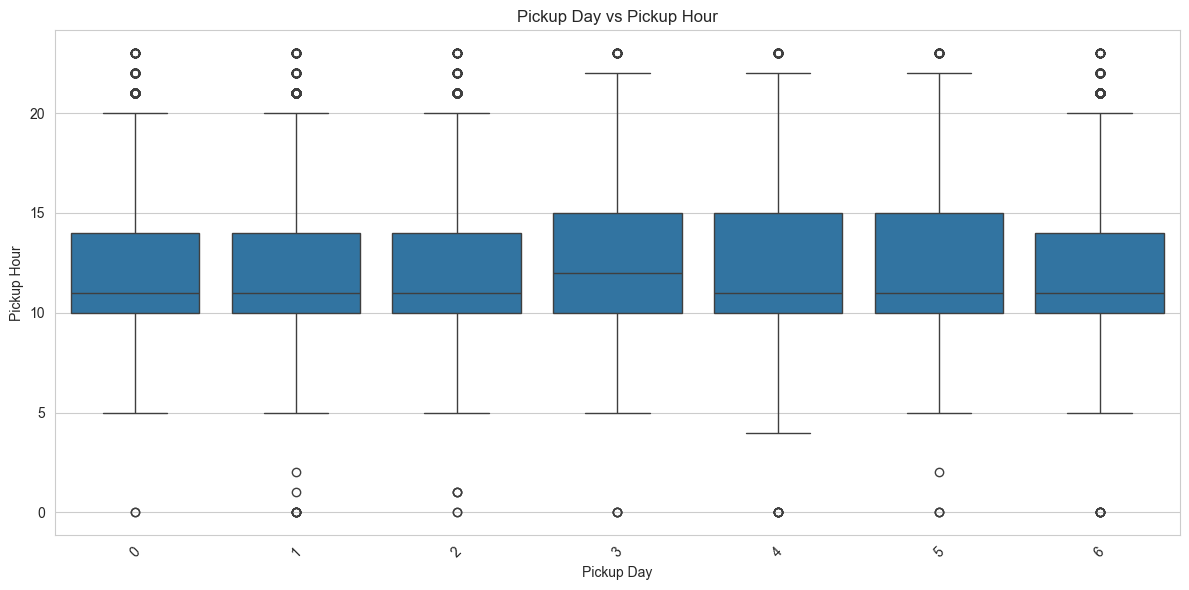

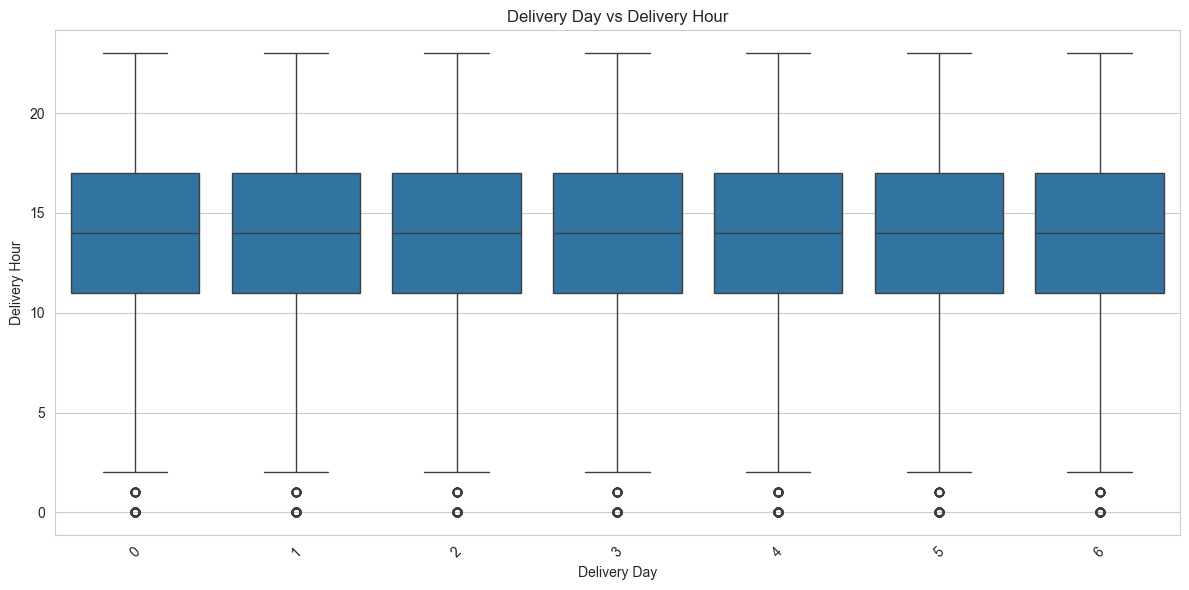

In [ ]:
pairs = {
    'Pickup City vs Pickup Hour': ['pickup_city', 'pickup_hour'],
    'Delivery City vs Delivery Hour': ['delivery_city', 'delivery_hour'],
    'Pickup AOI Type vs Pickup Hour': ['pickup_aoi_type', 'pickup_hour'],
    'Delivery AOI Type vs Delivery Hour': ['delivery_aoi_type', 'delivery_hour'],
    'Pickup Day vs Pickup Hour': ['pickup_day', 'pickup_hour'],
    'Delivery Day vs Delivery Hour': ['delivery_day', 'delivery_hour'],
}

sns.set_style("whitegrid")

for title, [x_col, y_col] in pairs.items():
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=dataset, x=x_col, y=y_col)
    plt.title(title)
    plt.xlabel(x_col.replace('_', ' ').title())
    plt.ylabel(y_col.replace('_', ' ').title())
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

- All five cities have median pickup times clustered around late morning (about 11 AM), but Hangzhou and Shanghai exhibit the greatest variability into both early‐morning and late‐evening hours, with each city showing occasional midnight outliers.
- Deliveries in all five cities cluster in the early afternoon, but Chongqing has the latest median delivery time (around 3 PM), Jilin the earliest (around noon), and Hangzhou shows the greatest variability spanning from pre-dawn to late evening.
- Pickup times are remarkably consistent across all AOI types, with medians clustered in the late-morning (around 11–12 PM) and mostly similar IQRs, suggesting area type has minimal impact on when pickups occur.
- Deliveries across most AOI types cluster in the early afternoon (around 1-3 PM) with very similar spreads, but AOI types 4 and 15 skew noticeably later with higher median delivery hours and wider variability, and all types still show a few overnight outliers.
- Pickup times are virtually uniform throughout the week-medians hover around 11 AM every day-with only a slight midweek (Wednesday / Thursday) bump in both median pickup hour and spread.
- Delivery times remain strikingly consistent across the week, with median deliveries around early afternoon (around 2 PM), similar spreads each day, and only a handful of overnight outliers.

#### ***Multivariate Analysis***

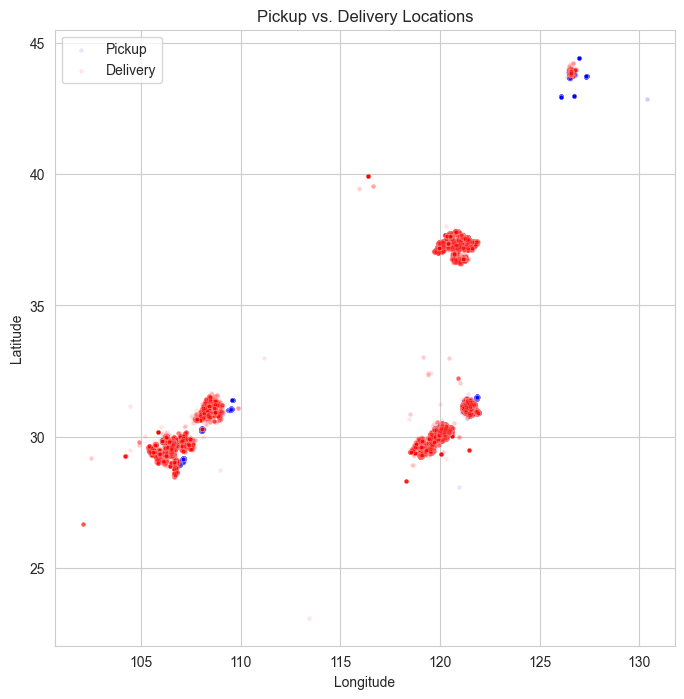

In [ ]:
plt.figure(figsize=(8, 8))
sns.scatterplot(x='pickup_lng', y='pickup_lat', data=dataset, s=10, alpha=0.1, color='blue', label='Pickup')
sns.scatterplot(x='delivery_lng', y='delivery_lat', data=dataset, s=10, alpha=0.1, color='red', label='Delivery')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Pickup vs. Delivery Locations')
plt.legend(loc='upper left')
plt.show()

Pickup and delivery points form nearly identical clusters, showing that the vast majority of orders both start and end within the same cities / place.

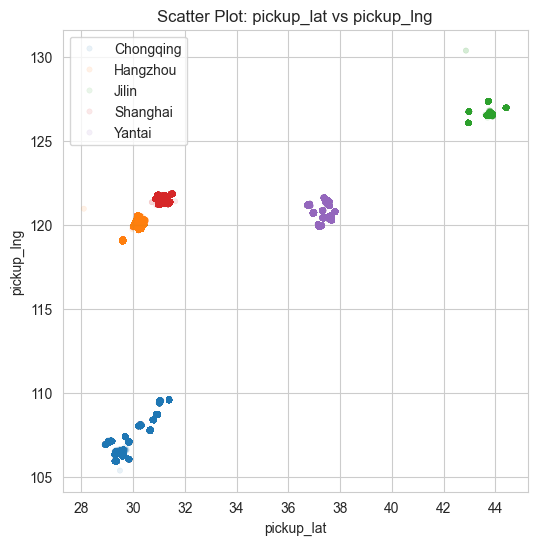

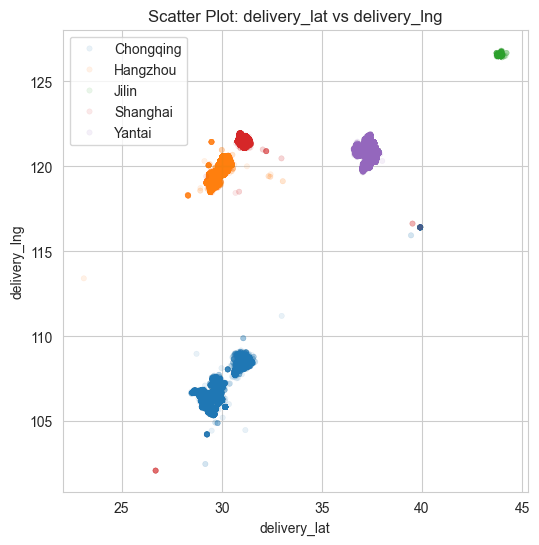

In [ ]:
pairs = {
    'pickup_lat vs pickup_lng': ['pickup_lat', 'pickup_lng', 'pickup_city'],
    'delivery_lat vs delivery_lng': ['delivery_lat', 'delivery_lng', 'delivery_city'],
}

sns.set_style('whitegrid')

for title, [x_col, y_col, hue] in pairs.items():
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=dataset, x=x_col, y=y_col, alpha=0.1, edgecolor=None, s=15, hue=hue, hue_order=['Chongqing', 'Hangzhou', 'Jilin', 'Shanghai', 'Yantai'])
    plt.title(f'Scatter Plot: {x_col} vs {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.legend(loc='upper left')
    plt.show()

Isolated min-max scaling can create the phantom outliers being shown.

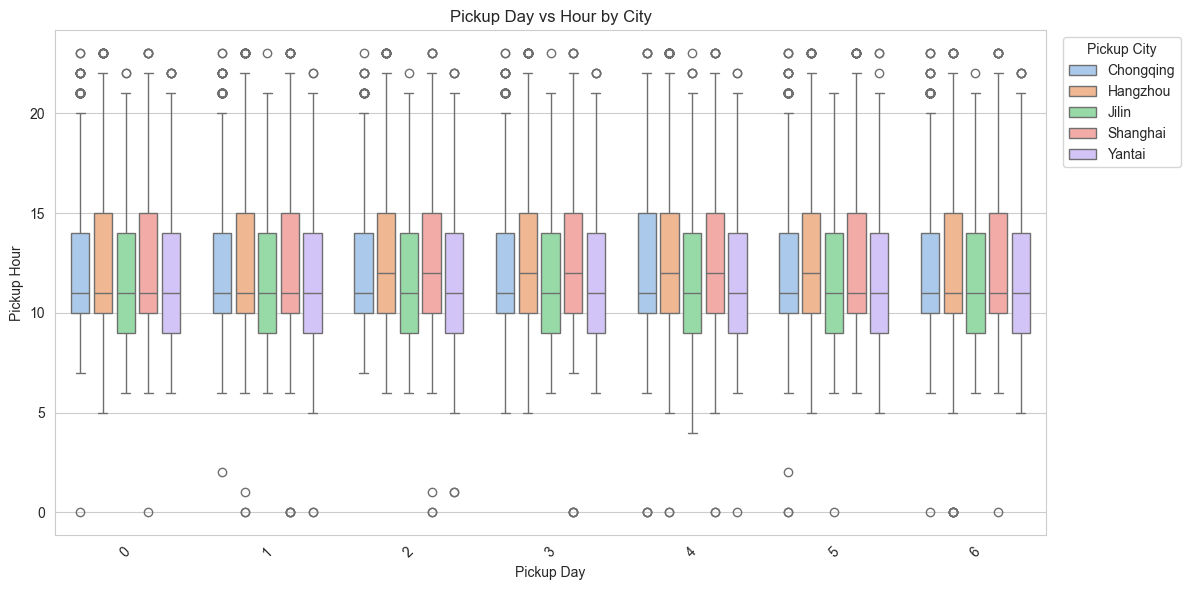

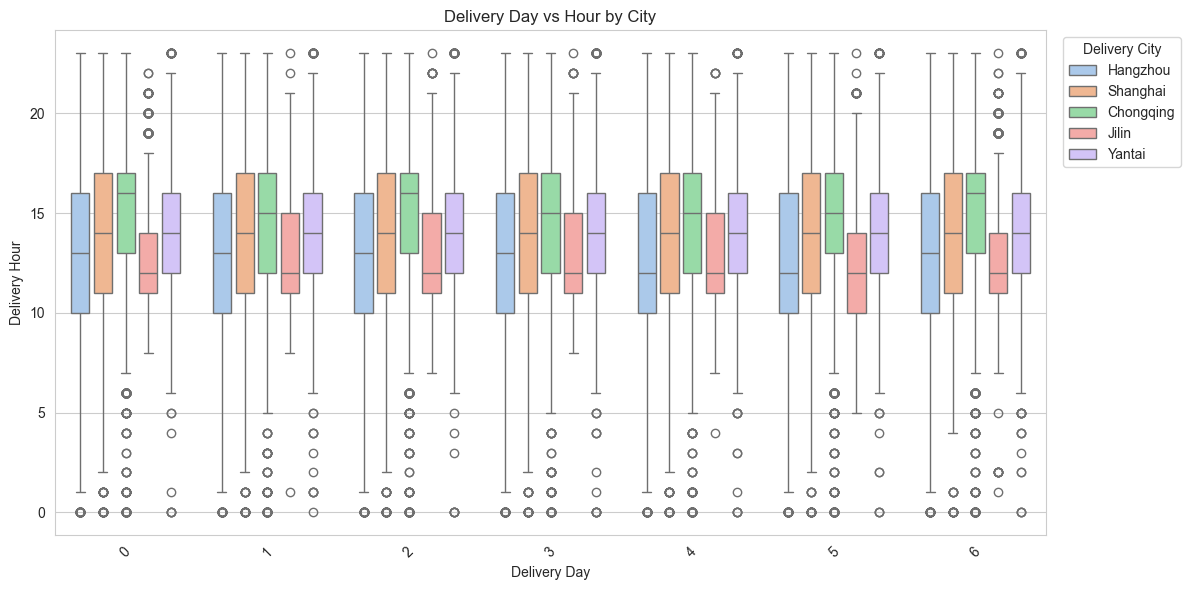

In [ ]:
sns.set_style("whitegrid")

pairs = {
    'Pickup Day vs Hour by City': ['pickup_day', 'pickup_hour', 'pickup_city'],
    'Delivery Day vs Hour by City': ['delivery_day', 'delivery_hour', 'delivery_city'],
}

for title, [x_col, y_col, hue] in pairs.items():
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=dataset, x=x_col, y=y_col, hue=hue, palette="pastel", gap=0.2 )
    plt.title(title)
    plt.xlabel(x_col.replace('_', ' ').title())
    plt.ylabel(y_col.replace('_', ' ').title())
    plt.legend(title=hue.replace('_', ' ').title(), bbox_to_anchor=(1.01, 1), loc='upper left')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

- Pickup times remain remarkably consistent day-to-day, with each city’s median firmly in the late morning, and only slight city-specific tweaks (Jilin tends earliest, Shanghai and Hangzhou edge a bit later midweek, and Yantai shows a touch more weekend spread).
- Deliveries are remarkably consistent day‐to‐day within each city, but offset by city, Chongqing (green) shows the latest median drop‐offs (mid‐ to late‐afternoon), Jilin (red) the earliest (around noon), and Hangzhou, Shanghai and Yantai all falling in between with similar tight spreads.

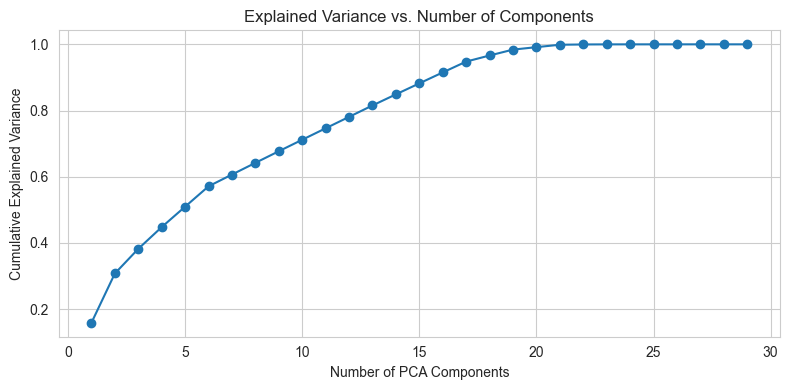

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

numeric_df = dataset.select_dtypes(include=[np.number])
scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_df)

pca = PCA()
pca.fit(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel('Number of PCA Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.tight_layout()
plt.show()

As shown in the graph, the cumulative variance curve, at 16 components we cross the 90 % threshold, and beyond that gains are minimal.

In [ ]:
pca = PCA(n_components=16)
X_reduced = pca.fit_transform(X_scaled)

print(f"Explained variance with {pca.n_components_} components: {pca.explained_variance_ratio_.sum() * 100 :.2f}%")


Explained variance with 16 components: 91.51%


In [ ]:
pc_cols = [f'PC{i+1}' for i in range(16)]
pca_df = pd.DataFrame(X_reduced, columns=pc_cols)

pca_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-3.547218,1.077937,-0.528935,1.150270,-0.101752,-0.596138,-0.976974,-0.539286,0.371970,-0.309839,-0.952687,-0.254538,-1.152207,1.324323,0.254321,-1.471562
1,-3.548276,-2.554877,2.290939,1.024749,-0.423145,-0.620598,-1.010206,0.280559,1.205960,-1.295717,-1.541479,1.302585,0.006829,1.052677,0.748281,-0.529083
2,-3.596984,0.162239,-0.791534,0.871541,-0.070282,-0.595568,-0.419695,1.439478,-0.145431,-0.675785,-0.400636,-0.759026,0.168588,0.766504,0.469090,0.686665
3,-3.605091,-0.040747,-0.439418,1.172597,-1.514695,-1.598832,0.285716,-0.679338,-0.895497,-0.144077,-0.571209,-0.400045,1.384479,0.550410,0.169802,-1.968970
4,-3.592999,0.250775,-0.942240,1.360336,-1.492522,-0.537322,-0.239596,1.919149,-0.998264,-0.943277,-1.394490,0.223723,-0.780789,0.073018,0.061757,-2.163478


In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=dataset.select_dtypes(include=['int32','int64','float32','float64']).columns.tolist(),
    columns=pca_df.columns
)

for pc in pca_df.columns:
    top_feats = loadings[pc].abs().nlargest(8)
    print(f"Top contributing features to {pc}:\n{top_feats}\n")

Top contributing features to PC1:
pickup_lat               0.415481
pickup_accept_gps_lat    0.415289
pickup_gps_lat           0.415242
pickup_gps_lng           0.383426
pickup_accept_gps_lng    0.383365
pickup_lng               0.382897
pickup_region_id         0.195782
pickup_aoi_type          0.048235
Name: PC1, dtype: float64

Top contributing features to PC2:
delivery_lng               0.422005
delivery_gps_lng           0.421302
delivery_accept_gps_lng    0.421132
delivery_accept_gps_lat    0.377186
delivery_gps_lat           0.376922
delivery_lat               0.376690
delivery_region_id         0.189347
delivery_hour              0.066035
Name: PC2, dtype: float64

Top contributing features to PC3:
delivery_region_id         0.450037
delivery_lat               0.415345
delivery_gps_lat           0.413470
delivery_accept_gps_lat    0.411999
delivery_lng               0.297598
delivery_accept_gps_lng    0.296772
delivery_gps_lng           0.295096
delivery_hour              0.120

PC1 and PC2 essentially encode where orders start and end geographically, so next you can use them (and additional PCs) to cluster or segment orders by region or include them as inputs in your predictive models.

In [ ]:
pca_df.to_csv("Processed Data//Delivery_Pickup_PCA.csv", index=False)

In [ ]:
%reset -f

# ***Week 3***
#### ***Loading Data***

In [ ]:
import pandas as pd
pd.set_option('display.max_columns', None)

dataset = pd.read_csv("Processed Data//Delivery_Pickup_Merged_Clean.csv",
                      parse_dates=['pickup_accept_time', 'time_window_start', 'time_window_end',
                                   'pickup_time', 'pickup_gps_time', 'pickup_accept_gps_time',
                                   'delivery_accept_time', 'delivery_accept_gps_time',
                                   'delivery_time', 'delivery_gps_time'])
dataset.head()

,order_id,pickup_region_id,pickup_city,pickup_courier_id,pickup_accept_time,time_window_start,time_window_end,pickup_lng,pickup_lat,pickup_aoi_id,pickup_aoi_type,pickup_time,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,pickup_accept_gps_time,pickup_accept_gps_lng,pickup_accept_gps_lat,pickup_ds,delivery_region_id,delivery_city,delivery_courier_id,delivery_lng,delivery_lat,delivery_aoi_id,delivery_aoi_type,delivery_accept_time,delivery_accept_gps_time,delivery_accept_gps_lng,delivery_accept_gps_lat,delivery_time,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,delivery_ds,delivery_hour,pickup_hour,delivery_day,pickup_day,delivery_weekend,pickup_weekend
0,483671,3,Chongqing,1518,2025-08-14 07:57:00,2025-08-14 09:00:00,2025-08-14 11:00:00,106.46877,29.47204,218,14,2025-08-14 09:38:00,2025-08-14 09:37:42,106.46896,29.468172,2025-08-14 07:56:05,106.47932,29.45298,814,44,Shanghai,2901,121.53381,31.24347,32352,0,2025-08-08 16:10:00,2025-08-08 16:10:00,121.54602,31.24282,2025-08-08 17:37:00,2025-08-08 17:37:00,121.53092,31.24168,808,17,9,4,3,0,0
1,1746131,3,Chongqing,4706,2025-10-09 07:46:00,2025-10-09 09:00:00,2025-10-09 11:00:00,106.46872,29.47200,218,14,2025-10-09 09:42:00,2025-10-09 09:41:42,106.46896,29.468172,2025-10-09 07:45:05,106.47932,29.45298,1009,163,Chongqing,4111,108.43148,30.75648,8286,1,2025-10-16 08:25:00,2025-10-16 08:25:00,108.46679,30.77499,2025-10-16 18:29:00,2025-10-16 18:29:00,108.43140,30.75642,1016,18,9,3,3,0,0
2,2301722,3,Chongqing,4706,2025-10-09 13:57:00,2025-10-09 13:57:00,2025-10-09 15:57:00,106.46869,29.47191,218,14,2025-10-09 15:53:00,2025-10-09 15:53:00,106.46821,29.467710,2025-10-09 13:56:00,106.46929,29.47231,1009,60,Hangzhou,4200,120.34996,30.22210,21195,9,2025-07-04 09:10:00,2025-07-04 09:10:00,120.29604,30.21248,2025-07-04 16:58:00,2025-07-04 16:58:00,120.31284,30.16966,704,16,15,4,3,0,0
3,3788723,3,Chongqing,4706,2025-05-19 08:13:00,2025-05-19 11:00:00,2025-05-19 13:00:00,106.46878,29.47208,218,14,2025-05-19 11:59:00,2025-05-19 11:58:42,106.46896,29.468172,2025-05-19 08:12:05,106.47932,29.45298,519,94,Hangzhou,2087,119.94159,30.24504,30236,1,2025-08-18 15:30:00,2025-08-18 15:30:00,119.96208,30.21133,2025-08-18 16:11:00,2025-08-18 16:11:00,119.94172,30.24447,818,16,11,0,0,0,0
4,713435,3,Chongqing,4706,2025-05-22 08:16:00,2025-05-22 09:00:00,2025-05-22 11:00:00,106.46813,29.47228,218,14,2025-05-22 10:40:00,2025-05-22 10:40:00,106.46827,29.472700,2025-05-22 08:15:05,106.47932,29.45298,522,60,Hangzhou,4779,120.37863,30.24086,10000,9,2025-08-18 08:53:00,2025-08-18 08:53:00,120.29610,30.21240,2025-08-18 12:58:00,2025-08-18 12:58:00,120.37463,30.23225,818,12,10,0,3,0,0


In [ ]:
int_cols = dataset.select_dtypes(include=['int64']).columns
dataset[int_cols] = dataset[int_cols].astype('int32')

float_cols = dataset.select_dtypes(include=['float64']).columns
dataset[float_cols] = dataset[float_cols].astype('float32')

#### ***Understanding the Domain and Problem Statement***

Given a combination of order, pickup, and delivery data (with location, courier, and timestamps), predict the expected duration/time until delivery milestones. Arrival-time predictions for package delivery, resource allocation, route optimization, customer notifications, etc. The target variable is not in the dataset, we have to create it.

In [ ]:
dataset["eta_accept_to_delivery_gps_time"] = (dataset["delivery_gps_time"] - dataset["delivery_accept_gps_time"]).dt.total_seconds() / 3600
dataset["eta_pickup_accept_gps_time"] = (dataset["pickup_gps_time"] - dataset["pickup_accept_gps_time"]).dt.total_seconds() / 3600
dataset["eta_pickup_to_delivery_gps_time"] = (dataset["delivery_gps_time"] - dataset["pickup_gps_time"]).dt.total_seconds() / 3600

dataset["ETA_target"] = dataset["eta_pickup_to_delivery_gps_time"]
dataset.head()

,order_id,pickup_region_id,pickup_city,pickup_courier_id,pickup_accept_time,time_window_start,time_window_end,pickup_lng,pickup_lat,pickup_aoi_id,pickup_aoi_type,pickup_time,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,pickup_accept_gps_time,pickup_accept_gps_lng,pickup_accept_gps_lat,pickup_ds,delivery_region_id,delivery_city,delivery_courier_id,delivery_lng,delivery_lat,delivery_aoi_id,delivery_aoi_type,delivery_accept_time,delivery_accept_gps_time,delivery_accept_gps_lng,delivery_accept_gps_lat,delivery_time,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,delivery_ds,delivery_hour,pickup_hour,delivery_day,pickup_day,delivery_weekend,pickup_weekend,eta_accept_to_delivery_gps_time,eta_pickup_accept_gps_time,eta_pickup_to_delivery_gps_time,ETA_target
0,483671,3,Chongqing,1518,2025-08-14 07:57:00,2025-08-14 09:00:00,2025-08-14 11:00:00,106.468773,29.472040,218,14,2025-08-14 09:38:00,2025-08-14 09:37:42,106.468964,29.468172,2025-08-14 07:56:05,106.479317,29.452980,814,44,Shanghai,2901,121.533813,31.243469,32352,0,2025-08-08 16:10:00,2025-08-08 16:10:00,121.546021,31.242821,2025-08-08 17:37:00,2025-08-08 17:37:00,121.530922,31.241680,808,17,9,4,3,0,0,1.450000,1.693611,-136.011667,-136.011667
1,1746131,3,Chongqing,4706,2025-10-09 07:46:00,2025-10-09 09:00:00,2025-10-09 11:00:00,106.468719,29.472000,218,14,2025-10-09 09:42:00,2025-10-09 09:41:42,106.468964,29.468172,2025-10-09 07:45:05,106.479317,29.452980,1009,163,Chongqing,4111,108.431480,30.756479,8286,1,2025-10-16 08:25:00,2025-10-16 08:25:00,108.466789,30.774990,2025-10-16 18:29:00,2025-10-16 18:29:00,108.431396,30.756420,1016,18,9,3,3,0,0,10.066667,1.943611,176.788333,176.788333
2,2301722,3,Chongqing,4706,2025-10-09 13:57:00,2025-10-09 13:57:00,2025-10-09 15:57:00,106.468689,29.471910,218,14,2025-10-09 15:53:00,2025-10-09 15:53:00,106.468208,29.467710,2025-10-09 13:56:00,106.469292,29.472309,1009,60,Hangzhou,4200,120.349960,30.222099,21195,9,2025-07-04 09:10:00,2025-07-04 09:10:00,120.296043,30.212481,2025-07-04 16:58:00,2025-07-04 16:58:00,120.312843,30.169661,704,16,15,4,3,0,0,7.800000,1.950000,-2326.916667,-2326.916667
3,3788723,3,Chongqing,4706,2025-05-19 08:13:00,2025-05-19 11:00:00,2025-05-19 13:00:00,106.468781,29.472080,218,14,2025-05-19 11:59:00,2025-05-19 11:58:42,106.468964,29.468172,2025-05-19 08:12:05,106.479317,29.452980,519,94,Hangzhou,2087,119.941589,30.245041,30236,1,2025-08-18 15:30:00,2025-08-18 15:30:00,119.962082,30.211330,2025-08-18 16:11:00,2025-08-18 16:11:00,119.941719,30.244471,818,16,11,0,0,0,0,0.683333,3.776944,2188.205000,2188.205000
4,713435,3,Chongqing,4706,2025-05-22 08:16:00,2025-05-22 09:00:00,2025-05-22 11:00:00,106.468132,29.472281,218,14,2025-05-22 10:40:00,2025-05-22 10:40:00,106.468269,29.472700,2025-05-22 08:15:05,106.479317,29.452980,522,60,Hangzhou,4779,120.378632,30.240860,10000,9,2025-08-18 08:53:00,2025-08-18 08:53:00,120.296097,30.212400,2025-08-18 12:58:00,2025-08-18 12:58:00,120.374634,30.232250,818,12,10,0,3,0,0,4.083333,2.415278,2114.300000,2114.300000


In [ ]:
dataset[[col for col in dataset.columns if 'time' in col]].head(10)

,pickup_accept_time,time_window_start,time_window_end,pickup_time,pickup_gps_time,pickup_accept_gps_time,delivery_accept_time,delivery_accept_gps_time,delivery_time,delivery_gps_time,eta_accept_to_delivery_gps_time,eta_pickup_accept_gps_time,eta_pickup_to_delivery_gps_time
0,2025-08-14 07:57:00,2025-08-14 09:00:00,2025-08-14 11:00:00,2025-08-14 09:38:00,2025-08-14 09:37:42,2025-08-14 07:56:05,2025-08-08 16:10:00,2025-08-08 16:10:00,2025-08-08 17:37:00,2025-08-08 17:37:00,1.450000,1.693611,-136.011667
1,2025-10-09 07:46:00,2025-10-09 09:00:00,2025-10-09 11:00:00,2025-10-09 09:42:00,2025-10-09 09:41:42,2025-10-09 07:45:05,2025-10-16 08:25:00,2025-10-16 08:25:00,2025-10-16 18:29:00,2025-10-16 18:29:00,10.066667,1.943611,176.788333
2,2025-10-09 13:57:00,2025-10-09 13:57:00,2025-10-09 15:57:00,2025-10-09 15:53:00,2025-10-09 15:53:00,2025-10-09 13:56:00,2025-07-04 09:10:00,2025-07-04 09:10:00,2025-07-04 16:58:00,2025-07-04 16:58:00,7.800000,1.950000,-2326.916667
3,2025-05-19 08:13:00,2025-05-19 11:00:00,2025-05-19 13:00:00,2025-05-19 11:59:00,2025-05-19 11:58:42,2025-05-19 08:12:05,2025-08-18 15:30:00,2025-08-18 15:30:00,2025-08-18 16:11:00,2025-08-18 16:11:00,0.683333,3.776944,2188.205000
4,2025-05-22 08:16:00,2025-05-22 09:00:00,2025-05-22 11:00:00,2025-05-22 10:40:00,2025-05-22 10:40:00,2025-05-22 08:15:05,2025-08-18 08:53:00,2025-08-18 08:53:00,2025-08-18 12:58:00,2025-08-18 12:58:00,4.083333,2.415278,2114.300000
5,2025-05-19 07:43:00,2025-05-19 09:00:00,2025-05-19 11:00:00,2025-05-19 09:56:00,2025-05-19 09:55:00,2025-05-19 07:42:05,2025-07-10 09:01:00,2025-07-10 09:01:00,2025-07-10 10:34:00,2025-07-10 10:34:00,1.550000,2.215278,1248.650000
6,2025-10-09 10:36:00,2025-10-09 17:00:00,2025-10-09 19:00:00,2025-10-09 18:44:00,2025-10-09 18:44:00,2025-10-09 10:35:05,2025-07-08 09:28:00,2025-07-08 09:28:00,2025-07-08 13:06:00,2025-07-08 13:06:00,3.633333,8.148611,-2237.633333
7,2025-05-17 09:17:00,2025-05-17 13:00:00,2025-05-17 15:00:00,2025-05-17 11:36:00,2025-05-17 11:36:00,2025-05-17 09:16:05,2025-09-09 16:57:00,2025-09-09 16:57:00,2025-09-09 17:29:00,2025-09-09 17:29:00,0.533333,2.331944,2765.883333
8,2025-05-21 13:18:00,2025-05-22 11:00:00,2025-05-22 13:00:00,2025-05-22 11:26:00,2025-05-22 11:25:00,2025-05-21 13:17:05,2025-10-05 09:05:00,2025-10-05 09:05:00,2025-10-05 13:29:00,2025-10-05 13:29:00,4.400000,22.131944,3266.066667
9,2025-05-06 07:57:00,2025-05-06 13:00:00,2025-05-06 15:00:00,2025-05-06 10:20:00,2025-05-06 10:19:00,2025-05-06 07:56:05,2025-08-03 14:20:00,2025-08-03 14:20:00,2025-08-03 16:05:00,2025-08-03 16:05:00,1.750000,2.381944,2141.766667


For each order, the correct temporal sequence should always be:
pickup_accept_time < pickup_time < delivery_accept_time < delivery_time

In [ ]:
print(f"Percentage of negative values in pcikup to delivery is {round(dataset[dataset['eta_pickup_to_delivery_gps_time'] < 0].shape[0] / dataset.shape[0] * 100, 2)} %")

Percentage of negative values in pcikup to delivery is 44.49 %


In [ ]:
valid_dataset = dataset[dataset['eta_pickup_to_delivery_gps_time'] >= 0]

After individually inspecting records, I confirmed that the high proportion of negative pickup-to-delivery ETAs is present in the original, unmerged data, indicating this is a systematic issue inherent in the source dataset rather than a result of any downstream data processing or merging.

This step was taken after confirming that negative ETAs were a systematic issue originating from the source data, and is necessary to ensure the validity of the features and target for ETA modeling.

In [ ]:
valid_dataset.info(memory_usage=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2491948 entries, 1 to 4488808
Data columns (total 45 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   order_id                         2491948 non-null  int32         
 1   pickup_region_id                 2491948 non-null  int32         
 2   pickup_city                      2491948 non-null  object        
 3   pickup_courier_id                2491948 non-null  int32         
 4   pickup_accept_time               2491948 non-null  datetime64[ns]
 5   time_window_start                2491948 non-null  datetime64[ns]
 6   time_window_end                  2491948 non-null  datetime64[ns]
 7   pickup_lng                       2491948 non-null  float32       
 8   pickup_lat                       2491948 non-null  float32       
 9   pickup_aoi_id                    2491948 non-null  int32         
 10  pickup_aoi_type                  24

1. Temporal Features
    - pickup_accept_time, pickup_time, delivery_accept_time, delivery_time : Core timestamps defining the various stages of the delivery process. Critical for calculating accurate ETA targets and understanding timing delays.

    - time_window_start, time_window_end : Define customer or operational delivery windows—essential for understanding constraints on delivery timing.

    - pickup_hour, delivery_hour, pickup_day, delivery_day, pickup_weekend, delivery_weekend : Capture time-of-day, day-of-week, and weekend effects—key drivers of traffic patterns, courier availability, and delivery efficiency.

    - GPS timestamp equivalents (pickup_gps_time, delivery_gps_time, pickup_accept_gps_time, delivery_accept_gps_time) : Subtly different timing data possibly linked to real-time tracking; useful for validating or enhancing ETA accuracy.

2. Spatial / Location Features
    - pickup_region_id, delivery_region_id, pickup_city, delivery_city : Regional and city-level identifiers capture broad geographic context—crucial as traffic, distance, and route difficulty vary greatly by geography.

    - pickup_aoi_id, delivery_aoi_id, pickup_aoi_type, delivery_aoi_type : Area-of-interest level detail outlining specific local zones or districts, useful for micro-level congestion, distance, or route factors.

    - pickup_lat, pickup_lng, delivery_lat, delivery_lng, and their GPS variants (e.g., pickup_gps_lat, pickup_gps_lng) : Precise geospatial coordinates essential for distance calculations, routing, and spatial clustering.

3. Derived ETA Features
    - eta_accept_to_delivery_gps_time, eta_pickup_accept_gps_time, eta_pickup_to_delivery_gps_time : Engineered target or intermediate duration features that summarize intervals of interest, critical for supervised learning.

    - ETA_target : The engineered target variable for modeling, usually based on one of the above intervals, critical for training predictive models.

#### ***Feature Selection***

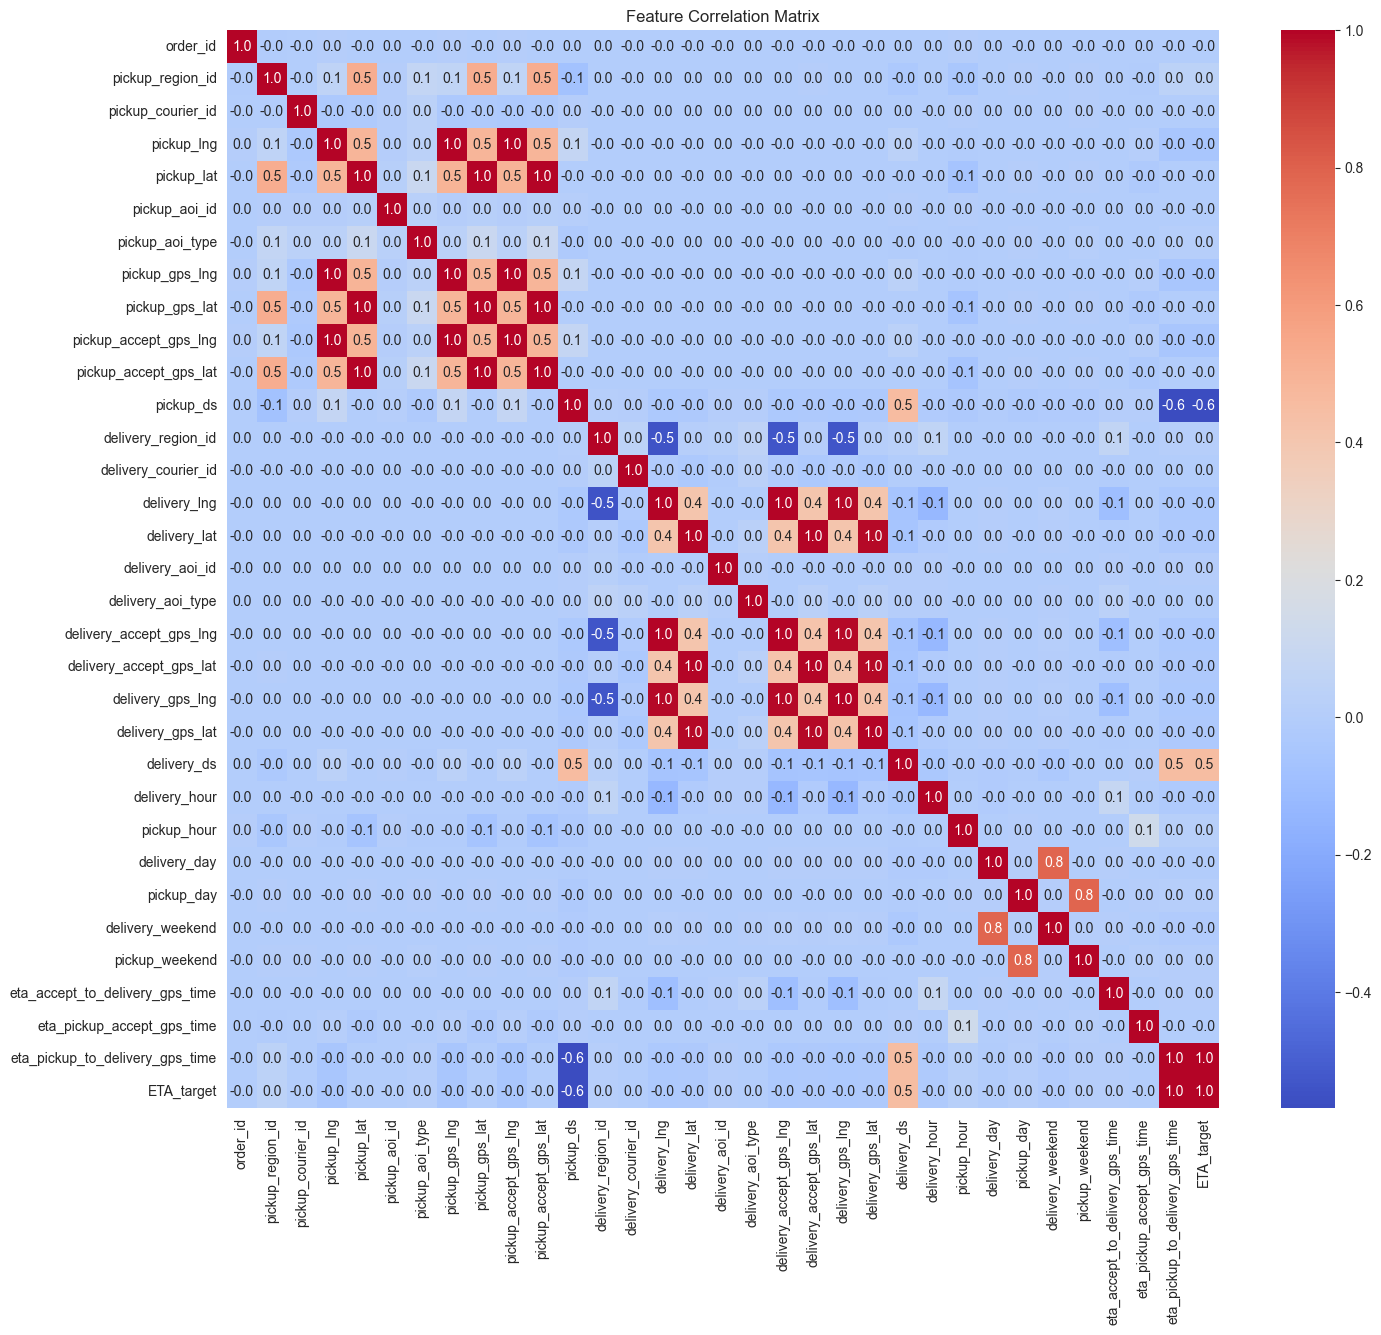

Highly correlated feature pairs (threshold > 0.90):
('pickup_gps_lng', 'pickup_lng', np.float64(0.9995590987154653))
('pickup_gps_lat', 'pickup_lat', np.float64(0.9995884507556605))
('pickup_accept_gps_lng', 'pickup_lng', np.float64(0.9994512676937745))
('pickup_accept_gps_lng', 'pickup_gps_lng', np.float64(0.9998163501163279))
('pickup_accept_gps_lat', 'pickup_lat', np.float64(0.9994869253769775))
('pickup_accept_gps_lat', 'pickup_gps_lat', np.float64(0.9997739227557231))
('delivery_accept_gps_lng', 'delivery_lng', np.float64(0.998598332354697))
('delivery_accept_gps_lat', 'delivery_lat', np.float64(0.9968933750662661))
('delivery_gps_lng', 'delivery_lng', np.float64(0.9904634344683108))
('delivery_gps_lng', 'delivery_accept_gps_lng', np.float64(0.9891052473435189))
('delivery_gps_lat', 'delivery_lat', np.float64(0.9931428741898664))
('delivery_gps_lat', 'delivery_accept_gps_lat', np.float64(0.9902854871356852))
('ETA_target', 'eta_pickup_to_delivery_gps_time', np.float64(1.0))


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = valid_dataset[valid_dataset.select_dtypes(include=['float64', 'float32', 'int32', 'int64']).columns].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()

threshold = 0.9
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            col1 = corr_matrix.columns[i]
            col2 = corr_matrix.columns[j]
            high_corr_pairs.append((col1, col2, corr_matrix.iloc[i, j]))

print("Highly correlated feature pairs (threshold > {:.2f}):".format(threshold))
for pair in high_corr_pairs:
    print(pair)

In [ ]:
valid_dataset = valid_dataset.drop(columns=[ 'pickup_lng', 'pickup_lat', 'delivery_lng',
                                            'pickup_accept_time', 'pickup_time', 'delivery_accept_time', 'delivery_time'])
valid_dataset.head()

,order_id,pickup_region_id,pickup_city,pickup_courier_id,time_window_start,time_window_end,pickup_aoi_id,pickup_aoi_type,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,pickup_accept_gps_time,pickup_accept_gps_lng,pickup_accept_gps_lat,pickup_ds,delivery_region_id,delivery_city,delivery_courier_id,delivery_lat,delivery_aoi_id,delivery_aoi_type,delivery_accept_gps_time,delivery_accept_gps_lng,delivery_accept_gps_lat,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,delivery_ds,delivery_hour,pickup_hour,delivery_day,pickup_day,delivery_weekend,pickup_weekend,eta_accept_to_delivery_gps_time,eta_pickup_accept_gps_time,eta_pickup_to_delivery_gps_time,ETA_target
1,1746131,3,Chongqing,4706,2025-10-09 09:00:00,2025-10-09 11:00:00,218,14,2025-10-09 09:41:42,106.468964,29.468172,2025-10-09 07:45:05,106.479317,29.45298,1009,163,Chongqing,4111,30.756479,8286,1,2025-10-16 08:25:00,108.466789,30.774990,2025-10-16 18:29:00,108.431396,30.756420,1016,18,9,3,3,0,0,10.066667,1.943611,176.788333,176.788333
3,3788723,3,Chongqing,4706,2025-05-19 11:00:00,2025-05-19 13:00:00,218,14,2025-05-19 11:58:42,106.468964,29.468172,2025-05-19 08:12:05,106.479317,29.45298,519,94,Hangzhou,2087,30.245041,30236,1,2025-08-18 15:30:00,119.962082,30.211330,2025-08-18 16:11:00,119.941719,30.244471,818,16,11,0,0,0,0,0.683333,3.776944,2188.205000,2188.205000
4,713435,3,Chongqing,4706,2025-05-22 09:00:00,2025-05-22 11:00:00,218,14,2025-05-22 10:40:00,106.468269,29.472700,2025-05-22 08:15:05,106.479317,29.45298,522,60,Hangzhou,4779,30.240860,10000,9,2025-08-18 08:53:00,120.296097,30.212400,2025-08-18 12:58:00,120.374634,30.232250,818,12,10,0,3,0,0,4.083333,2.415278,2114.300000,2114.300000
5,2718201,3,Chongqing,4706,2025-05-19 09:00:00,2025-05-19 11:00:00,218,14,2025-05-19 09:55:00,106.468063,29.472771,2025-05-19 07:42:05,106.479317,29.45298,519,8,Shanghai,3514,31.141939,51187,1,2025-07-10 09:01:00,121.493629,31.138750,2025-07-10 10:34:00,121.530502,31.143459,710,10,9,3,0,0,0,1.550000,2.215278,1248.650000,1248.650000
7,2308168,3,Chongqing,4706,2025-05-17 13:00:00,2025-05-17 15:00:00,218,14,2025-05-17 11:36:00,106.470078,29.470850,2025-05-17 09:16:05,106.479317,29.45298,517,65,Shanghai,812,31.161591,28547,1,2025-09-09 16:57:00,121.444443,31.168409,2025-09-09 17:29:00,121.431374,31.161261,909,17,11,1,5,0,1,0.533333,2.331944,2765.883333,2765.883333


#### ***Create New Features***

In [ ]:
valid_dataset["time_window_length_mins"] = (valid_dataset["time_window_end"] - valid_dataset["time_window_start"]).dt.total_seconds() / 3600
valid_dataset["pickup_delivery_time_ratio"] = valid_dataset["eta_pickup_accept_gps_time"] / (valid_dataset["eta_accept_to_delivery_gps_time"] + 1e-6)

In [ ]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1_rad, lon1_rad = np.radians(lat1), np.radians(lon1)
    lat2_rad, lon2_rad = np.radians(lat2), np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = np.sin(dlat/2)**2 + np.cos(lat1_rad)*np.cos(lat2_rad)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance = R * c
    return distance

valid_dataset["distance_km"] = haversine(valid_dataset["pickup_gps_lat"], valid_dataset["pickup_gps_lng"], valid_dataset["delivery_gps_lat"], valid_dataset["delivery_gps_lng"])

valid_dataset["speed_kmh"] = valid_dataset["distance_km"] / (valid_dataset["eta_pickup_to_delivery_gps_time"] + 1e-6)

In [ ]:
valid_dataset['month'] = valid_dataset['time_window_start'].dt.month
valid_dataset['quarter'] = valid_dataset['time_window_start'].dt.quarter

Aggregate data based on categories or time, deriving statistics such as mean, sum, or count. Since the file is too large already, presenting pivot tables is a good solution to address file size and loading time challenges while still delivering valuable aggregated insights to stakeholders or for initial analysis.

In [ ]:
valid_dataset.pivot_table(
    values='speed_kmh',
    index='pickup_city',
    columns='month',
    aggfunc='mean'
).fillna(0)

month,4,5,6,7,8,9,10,11
pickup_city,,,,,,,,
Chongqing,0.344695,2.892214,9828.357277,12911.678873,9.144014,1626.169609,463.035233,10.835306
Hangzhou,0.090390,1.099166,1.617624,1.553598,1500.760830,2110.527736,13658.394578,0.000000
Jilin,0.000000,133029.838341,9.732184,8.058469,11.005510,18.513782,90.947430,97.921234
Shanghai,0.000000,0.744401,1.957513,1132.659998,1831.309133,5.283923,6113.815491,0.000000
Yantai,0.559603,2.391512,6041.795625,7765.432273,7.712024,15879.848684,42758.334916,0.000000


The pivot table shows the monthly mean pickup activity across five Chinese cities. Jilin records an exceptionally high value in May, while Yantai shows significant spikes in June, July, and especially October, indicating seasonal or event-driven demand surges.

In [ ]:
valid_dataset.pivot_table(
    values='order_id',
    index='pickup_city',
    columns='quarter',
    aggfunc='count'
).fillna(0)

quarter,2,3,4
pickup_city,,,
Chongqing,270913,211654,19751
Hangzhou,458029,383845,38242
Jilin,46271,53642,4689
Shanghai,181992,312125,28256
Yantai,253040,209916,19583


Hangzhou consistently leads in total pickups across all quarters, while Jilin has the lowest counts, indicating lower overall demand or activity in that city.

In [ ]:
valid_dataset.pivot_table(
    values=['distance_km', 'speed_kmh'],
    index='pickup_hour',
    aggfunc='mean'
).fillna(0).T

pickup_hour,0,1,2,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
distance_km,504.853027,731.844116,223.915009,1469.180420,794.198547,868.464417,886.767639,747.134155,709.966003,701.353394,668.727112,657.558105,660.104919,677.660217,664.870544,647.044189,663.334290,701.589600,641.167175,625.789246,603.169373,559.031433,460.892365
speed_kmh,0.433650,1.615966,0.225250,3.172148,1.406277,1.191415,3.542475,4.445375,3304.918494,8936.592206,1160.474370,1026.152725,138.233203,4060.245873,9383.560594,154.849147,5879.276066,10583.651027,1.905387,2.513805,1.379181,1.398704,1.385908


This mean pivot table by pickup hour shows that distance traveled is relatively consistent throughout the day, with peaks around early morning (4–8 AM). However, the speed values indicate extremely high anomalies between 8 AM and 5 PM (e.g., 8936.6 km/h at 9 AM), suggesting likely data quality issues or calculation errors in the speed column during these hours.

In [ ]:
valid_dataset.pivot_table(
    values='eta_pickup_to_delivery_gps_time',
    index='delivery_city',
    columns='delivery_hour',
    aggfunc='median'
).fillna(0)

delivery_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
delivery_city,,,,,,,,,,,,,,,,,,,,,,,,
Chongqing,1407.833333,1262.483333,953.271667,2284.150000,1429.110833,1121.858333,1334.466667,1623.627500,1530.405000,1534.119167,1536.916667,1602.788333,1586.941667,1586.025000,1324.275000,1301.983333,1327.475000,1351.044167,1376.271667,1372.683333,1324.625000,1283.883333,1305.344167,1281.060833
Hangzhou,1391.071667,1514.575000,1690.800000,1589.460833,868.066667,950.750000,1060.302500,1076.300000,1247.750000,1272.550000,1316.383333,1340.144167,1363.627500,1388.302500,1324.533333,1221.383333,1321.033333,1396.716667,1328.666667,1306.566667,1279.016667,1279.475000,1232.083333,1229.269167
Jilin,0.000000,0.000000,0.000000,0.000000,0.000000,709.038333,0.000000,303.505000,1013.044167,1233.200000,1150.871667,1170.850000,1131.183333,1197.233333,1175.841667,1058.133333,1080.977500,944.455000,966.700000,1037.035833,832.583333,789.769167,1141.483333,561.669167
Shanghai,1441.485833,1308.883333,1238.235833,640.975000,570.371667,974.966667,1422.850000,1266.346667,1412.255000,1413.738333,1412.638333,1392.950000,1394.150000,1390.600000,1374.050000,1350.310833,1376.183333,1350.950000,1321.033333,1283.466667,1252.916667,1184.935833,1116.950000,965.171667
Yantai,805.802500,1332.483333,544.483333,833.121667,1841.916667,1668.966667,1292.010833,1246.966667,1040.191667,1017.135833,1198.250000,1220.850000,1225.400000,1276.450000,1270.005000,1296.250000,1303.319167,1274.550000,1329.516667,1280.216667,1252.016667,1172.483333,1181.085833,1430.550000


This median pivot table shows delivery durations (in hours) by delivery hour for five cities. Chongqing and Shanghai maintain consistently high delivery values across most hours, while Jilin has missing or zero values in the early hours, indicating minimal or no activity during that time.

#### ***Feature Transformation***

In [ ]:
with_log = valid_dataset.copy()
numeric_cols = with_log.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns

for col in numeric_cols:
    skewness = with_log[col].skew()
    if abs(skewness) > 1.5:
        print(f"Skewness of {col}: {skewness}")
        with_log[col] = np.log1p(with_log[col].clip(lower=0))

Skewness of pickup_gps_lat: 1.6109519004821777
Skewness of pickup_accept_gps_lat: 1.6119959354400635
Skewness of delivery_lat: 4.097949028015137
Skewness of delivery_accept_gps_lat: 4.0698347091674805
Skewness of delivery_gps_lng: -1.7325962781906128
Skewness of delivery_gps_lat: 3.796985149383545
Skewness of eta_accept_to_delivery_gps_time: 79.25117743065857
Skewness of eta_pickup_accept_gps_time: 9.320282459950985
Skewness of time_window_length_mins: 11.598222605714593
Skewness of pickup_delivery_time_ratio: 93.13814794981764
Skewness of speed_kmh: 616.7537409245633


In [ ]:
with_log.to_csv("Processed Data//DP_ETA_Valid_Log.csv", index=False)
del with_log

In [ ]:
from sklearn.preprocessing import MinMaxScaler

with_minmax = valid_dataset.copy()
numeric_cols = with_minmax.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns

scaler = MinMaxScaler()
with_minmax[numeric_cols] = scaler.fit_transform(with_minmax[numeric_cols])

In [ ]:
with_minmax.to_csv("Processed Data//DP_ETA_Valid_MM.csv", index=False)
del with_minmax

In [ ]:
from sklearn.preprocessing import StandardScaler

with_zscore = valid_dataset.copy()
numeric_cols = with_zscore.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns

scaler = StandardScaler()
with_zscore[numeric_cols] = scaler.fit_transform(with_zscore[numeric_cols])

In [ ]:
with_zscore.to_csv("Processed Data//DP_ETA_Valid_ZScore.csv", index=False)
del with_zscore

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

numeric_cols = [
    'eta_accept_to_delivery_gps_time', 'eta_pickup_accept_gps_time',
    'eta_pickup_to_delivery_gps_time', 'ETA_target',
    'time_window_length_mins', 'pickup_delivery_time_ratio',
    'distance_km', 'speed_kmh', 'delivery_hour', 'pickup_hour',
    'delivery_day', 'pickup_day', 'delivery_weekend',
    'pickup_weekend', 'month', 'quarter'
]
X = valid_dataset[numeric_cols]

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_poly = poly.fit_transform(X)

feature_names = poly.get_feature_names_out(numeric_cols)
valid_dataset_poly = pd.DataFrame(X_poly, columns=feature_names)
valid_dataset_poly.head()

,eta_accept_to_delivery_gps_time,eta_pickup_accept_gps_time,eta_pickup_to_delivery_gps_time,ETA_target,time_window_length_mins,pickup_delivery_time_ratio,distance_km,speed_kmh,delivery_hour,pickup_hour,delivery_day,pickup_day,delivery_weekend,pickup_weekend,month,quarter,eta_accept_to_delivery_gps_time eta_pickup_accept_gps_time,eta_accept_to_delivery_gps_time eta_pickup_to_delivery_gps_time,eta_accept_to_delivery_gps_time ETA_target,eta_accept_to_delivery_gps_time time_window_length_mins,eta_accept_to_delivery_gps_time pickup_delivery_time_ratio,eta_accept_to_delivery_gps_time distance_km,eta_accept_to_delivery_gps_time speed_kmh,eta_accept_to_delivery_gps_time delivery_hour,eta_accept_to_delivery_gps_time pickup_hour,eta_accept_to_delivery_gps_time delivery_day,eta_accept_to_delivery_gps_time pickup_day,eta_accept_to_delivery_gps_time delivery_weekend,eta_accept_to_delivery_gps_time pickup_weekend,eta_accept_to_delivery_gps_time month,eta_accept_to_delivery_gps_time quarter,eta_pickup_accept_gps_time eta_pickup_to_delivery_gps_time,eta_pickup_accept_gps_time ETA_target,eta_pickup_accept_gps_time time_window_length_mins,eta_pickup_accept_gps_time pickup_delivery_time_ratio,eta_pickup_accept_gps_time distance_km,eta_pickup_accept_gps_time speed_kmh,eta_pickup_accept_gps_time delivery_hour,eta_pickup_accept_gps_time pickup_hour,eta_pickup_accept_gps_time delivery_day,eta_pickup_accept_gps_time pickup_day,eta_pickup_accept_gps_time delivery_weekend,eta_pickup_accept_gps_time pickup_weekend,eta_pickup_accept_gps_time month,eta_pickup_accept_gps_time quarter,eta_pickup_to_delivery_gps_time ETA_target,eta_pickup_to_delivery_gps_time time_window_length_mins,eta_pickup_to_delivery_gps_time pickup_delivery_time_ratio,eta_pickup_to_delivery_gps_time distance_km,eta_pickup_to_delivery_gps_time speed_kmh,eta_pickup_to_delivery_gps_time delivery_hour,eta_pickup_to_delivery_gps_time pickup_hour,eta_pickup_to_delivery_gps_time delivery_day,eta_pickup_to_delivery_gps_time pickup_day,eta_pickup_to_delivery_gps_time delivery_weekend,eta_pickup_to_delivery_gps_time pickup_weekend,eta_pickup_to_delivery_gps_time month,eta_pickup_to_delivery_gps_time quarter,ETA_target time_window_length_mins,ETA_target pickup_delivery_time_ratio,ETA_target distance_km,ETA_target speed_kmh,ETA_target delivery_hour,ETA_target pickup_hour,ETA_target delivery_day,ETA_target pickup_day,ETA_target delivery_weekend,ETA_target pickup_weekend,ETA_target month,ETA_target quarter,time_window_length_mins pickup_delivery_time_ratio,time_window_length_mins distance_km,time_window_length_mins speed_kmh,time_window_length_mins delivery_hour,time_window_length_mins pickup_hour,time_window_length_mins delivery_day,time_window_length_mins pickup_day,time_window_length_mins delivery_weekend,time_window_length_mins pickup_weekend,time_window_length_mins month,time_window_length_mins quarter,pickup_delivery_time_ratio distance_km,pickup_delivery_time_ratio speed_kmh,pickup_delivery_time_ratio delivery_hour,pickup_delivery_time_ratio pickup_hour,pickup_delivery_time_ratio delivery_day,pickup_delivery_time_ratio pickup_day,pickup_delivery_time_ratio delivery_weekend,pickup_delivery_time_ratio pickup_weekend,pickup_delivery_time_ratio month,pickup_delivery_time_ratio quarter,distance_km speed_kmh,distance_km delivery_hour,distance_km pickup_hour,distance_km delivery_day,distance_km pickup_day,distance_km delivery_weekend,distance_km pickup_weekend,distance_km month,distance_km quarter,speed_kmh delivery_hour,speed_kmh pickup_hour,speed_kmh delivery_day,speed_kmh pickup_day,speed_kmh delivery_weekend,speed_kmh pickup_weekend,speed_kmh month,speed_kmh quarter,delivery_hour pickup_hour,delivery_hour delivery_day,delivery_hour pickup_day,delivery_hour delivery_weekend,delivery_hour pickup_weekend,delivery_hour month,delivery_hour quarter,pickup_hour delivery_day,pickup_hour pickup_day,pickup_hour delivery_weekend,pickup_hour pickup_weekend,pickup_hour month,pickup_hour quarter,delivery_day 

In [ ]:
valid_dataset_poly.to_csv("Processed Data//DP_ETA_Valid_Poly_Interaction.csv", index=False)
del valid_dataset_poly

In [ ]:
from sklearn.preprocessing import QuantileTransformer

quantile_transformer = QuantileTransformer(output_distribution='normal')  # or 'uniform' for uniform dist

valid_dataset_quant = valid_dataset.copy()
valid_dataset_quant[numeric_cols] = quantile_transformer.fit_transform(valid_dataset[numeric_cols])
valid_dataset_quant.head()

,order_id,pickup_region_id,pickup_city,pickup_courier_id,time_window_start,time_window_end,pickup_aoi_id,pickup_aoi_type,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,pickup_accept_gps_time,pickup_accept_gps_lng,pickup_accept_gps_lat,pickup_ds,delivery_region_id,delivery_city,delivery_courier_id,delivery_lat,delivery_aoi_id,delivery_aoi_type,delivery_accept_gps_time,delivery_accept_gps_lng,delivery_accept_gps_lat,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,delivery_ds,delivery_hour,pickup_hour,delivery_day,pickup_day,delivery_weekend,pickup_weekend,eta_accept_to_delivery_gps_time,eta_pickup_accept_gps_time,eta_pickup_to_delivery_gps_time,ETA_target,time_window_length_mins,pickup_delivery_time_ratio,distance_km,speed_kmh,month,quarter
1,1746131,3,Chongqing,4706,2025-10-09 09:00:00,2025-10-09 11:00:00,218,14,2025-10-09 09:41:42,106.468964,29.468172,2025-10-09 07:45:05,106.479317,29.45298,1009,163,Chongqing,4111,30.756479,8286,1,2025-10-16 08:25:00,108.466789,30.774990,2025-10-16 18:29:00,108.431396,30.756420,1016,1.125776,-1.012474,0.042668,-0.018820,-5.199338,-5.199338,1.888594,-0.023839,-1.406323,-1.406323,0.012546,-1.217023,-0.109764,0.855839,5.199338,5.199338
3,3788723,3,Chongqing,4706,2025-05-19 11:00:00,2025-05-19 13:00:00,218,14,2025-05-19 11:58:42,106.468964,29.468172,2025-05-19 08:12:05,106.479317,29.45298,519,94,Hangzhou,2087,30.245041,30236,1,2025-08-18 15:30:00,119.962082,30.211330,2025-08-18 16:11:00,119.941719,30.244471,818,0.464007,-0.100535,-5.199338,-5.199338,-5.199338,-5.199338,-0.971436,0.791686,0.613496,0.613496,0.012546,1.105332,0.517835,0.281918,-5.199338,-5.199338
4,713435,3,Chongqing,4706,2025-05-22 09:00:00,2025-05-22 11:00:00,218,14,2025-05-22 10:40:00,106.468269,29.472700,2025-05-22 08:15:05,106.479317,29.45298,522,60,Hangzhou,4779,30.240860,10000,9,2025-08-18 08:53:00,120.296097,30.212400,2025-08-18 12:58:00,120.374634,30.232250,818,-0.366873,-0.471004,-5.199338,-0.018820,-5.199338,-5.199338,0.953493,0.265284,0.551001,0.551001,0.012546,-0.477504,0.804171,0.335139,-5.199338,-5.199338
5,2718201,3,Chongqing,4706,2025-05-19 09:00:00,2025-05-19 11:00:00,218,14,2025-05-19 09:55:00,106.468063,29.472771,2025-05-19 07:42:05,106.479317,29.45298,519,8,Shanghai,3514,31.141939,51187,1,2025-07-10 09:01:00,121.493629,31.138750,2025-07-10 10:34:00,121.530502,31.143459,710,-1.044409,-1.012474,0.042668,-5.199338,-5.199338,-5.199338,-0.104318,0.149853,-0.089885,-0.089885,0.012546,0.167667,1.165463,0.761143,-5.199338,-5.199338
7,2308168,3,Chongqing,4706,2025-05-17 13:00:00,2025-05-17 15:00:00,218,14,2025-05-17 11:36:00,106.470078,29.470850,2025-05-17 09:16:05,106.479317,29.45298,517,65,Shanghai,812,31.161591,28547,1,2025-09-09 16:57:00,121.444443,31.168409,2025-09-09 17:29:00,121.431374,31.161261,909,0.786745,-0.100535,-0.778225,0.802226,-5.199338,5.199338,-1.228607,0.216204,1.062727,1.062727,0.012546,0.961846,1.068631,0.185255,-5.199338,-5.199338


In [ ]:
valid_dataset_quant.to_csv("Processed Data//DP_ETA_Valid_Quant.csv", index=False)
del valid_dataset_quant

#### ***Feature SCaling***

In [ ]:
from sklearn.preprocessing import RobustScaler
with_robust = valid_dataset.copy()

numeric_cols = with_robust.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns

scaler = RobustScaler()
with_robust[numeric_cols] = scaler.fit_transform(with_robust[numeric_cols])
with_robust.head()

,order_id,pickup_region_id,pickup_city,pickup_courier_id,time_window_start,time_window_end,pickup_aoi_id,pickup_aoi_type,pickup_gps_time,pickup_gps_lng,pickup_gps_lat,pickup_accept_gps_time,pickup_accept_gps_lng,pickup_accept_gps_lat,pickup_ds,delivery_region_id,delivery_city,delivery_courier_id,delivery_lat,delivery_aoi_id,delivery_aoi_type,delivery_accept_gps_time,delivery_accept_gps_lng,delivery_accept_gps_lat,delivery_gps_time,delivery_gps_lng,delivery_gps_lat,delivery_ds,delivery_hour,pickup_hour,delivery_day,pickup_day,delivery_weekend,pickup_weekend,eta_accept_to_delivery_gps_time,eta_pickup_accept_gps_time,eta_pickup_to_delivery_gps_time,ETA_target,time_window_length_mins,pickup_delivery_time_ratio,distance_km,speed_kmh,month,quarter
1,-0.232035,-1.048387,Chongqing,-0.416425,2025-10-09 09:00:00,2025-10-09 11:00:00,-0.973116,1.0,2025-10-09 09:41:42,-9.658440,-0.827480,2025-10-09 07:45:05,-9.632977,-0.839521,1.519802,1.240000,Chongqing,0.739732,0.413845,-0.733362,0.000000,2025-10-16 08:25:00,-8.101080,0.412702,2025-10-16 18:29:00,-8.190490,0.413272,0.487437,0.666667,-0.4,0.00,0.00,0.0,0.0,3.656934,-0.017293,-0.715469,-0.715469,0.0,-0.388572,-0.380101,1.010499,1.5,1.0
3,0.675775,-1.048387,Chongqing,-0.416425,2025-05-19 11:00:00,2025-05-19 13:00:00,-0.973116,1.0,2025-05-19 11:58:42,-9.658440,-0.827480,2025-05-19 08:12:05,-9.632977,-0.839521,-0.905941,0.320000,Hangzhou,-0.108550,-0.067083,0.005148,0.000000,2025-08-18 15:30:00,-0.202161,-0.107428,2025-08-18 16:11:00,-0.225413,-0.067820,-0.507538,0.333333,0.0,-0.75,-0.75,0.0,0.0,-0.452555,0.809774,0.512652,0.512652,0.0,1.832991,0.502122,0.214952,-1.0,-1.0
4,-0.691006,-1.048387,Chongqing,-0.416425,2025-05-22 09:00:00,2025-05-22 11:00:00,-0.973116,1.0,2025-05-22 10:40:00,-9.658926,-0.823575,2025-05-22 08:15:05,-9.632977,-0.839521,-0.891089,-0.133333,Hangzhou,1.019698,-0.071014,-0.675695,1.333333,2025-08-18 08:53:00,0.027355,-0.106441,2025-08-18 12:58:00,0.074161,-0.079304,-0.507538,-0.333333,-0.2,-0.75,0.00,0.0,0.0,1.036496,0.195489,0.467528,0.467528,0.0,-0.222637,0.536590,0.258119,-1.0,-1.0
5,0.199992,-1.048387,Chongqing,-0.416425,2025-05-19 09:00:00,2025-05-19 11:00:00,-0.973116,1.0,2025-05-19 09:55:00,-9.659070,-0.823514,2025-05-19 07:42:05,-9.632977,-0.839521,-0.905941,-0.826667,Shanghai,0.489522,0.776310,0.710046,0.000000,2025-07-10 09:01:00,0.850233,0.748369,2025-07-10 10:34:00,0.874015,0.776983,-1.050251,-0.666667,-0.4,0.00,-0.75,0.0,0.0,-0.072993,0.105263,-0.061017,-0.061017,0.0,0.126253,0.630846,0.825136,-1.0,-1.0
7,0.017757,-1.048387,Chongqing,-0.416425,2025-05-17 13:00:00,2025-05-17 15:00:00,-0.973116,1.0,2025-05-17 11:36:00,-9.657660,-0.825170,2025-05-17 09:16:05,-9.632977,-0.839521,-0.915842,-0.066667,Shanghai,-0.642917,0.794789,-0.051679,0.000000,2025-09-09 16:57:00,0.816434,0.775738,2025-09-09 17:29:00,0.805419,0.793711,-0.050251,0.500000,0.0,-0.50,0.50,0.0,1.0,-0.518248,0.157895,0.865368,0.865368,0.0,1.352024,0.623020,0.138690,-1.0,-1.0


In [ ]:
with_robust.to_csv("Processed Data//DP_ETA_Valid_RobustScale.csv", index=False)
del with_robust

max-Abs Scaling was not applied as the dataset is dense (2.5M rows) and not sparse — this scaler is more suitable for sparse data like one-hot encoded features.

#### ***Feature Reduction***

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

with_zscore = valid_dataset.copy()
numeric_cols = with_zscore.select_dtypes(include=['int32', 'int64', 'float32', 'float64']).columns

scaler = StandardScaler()
with_zscore[numeric_cols] = scaler.fit_transform(with_zscore[numeric_cols])

city_mapping = {city: idx for idx, city in enumerate(valid_dataset['pickup_city'].unique())}
with_zscore['pickup_city_mapped'] = valid_dataset['pickup_city'].map(city_mapping)
with_zscore['delivery_city_mapped'] = valid_dataset['delivery_city'].map(city_mapping)

features_for_pca = numeric_cols.tolist() + ['pickup_city_mapped', 'delivery_city_mapped']
pca_input = with_zscore[features_for_pca]

pca = PCA(n_components=0.95)
pca_result = pca.fit_transform(pca_input)

with_pca = pd.DataFrame(pca_result, columns=[f'PC{i+1}' for i in range(pca_result.shape[1])])
with_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24
0,-2.284222,-2.712199,4.962386,2.057805,1.128204,-0.275276,-0.134335,-0.485495,-0.834731,0.285057,-0.002053,0.266496,0.143309,-1.570285,-0.652928,0.866055,-0.823078,1.572821,1.323774,-1.503432,0.026417,-0.490207,0.411761,1.088650
1,0.033154,-3.952642,-1.413576,0.401578,-0.168158,-1.652362,-1.539831,0.681388,-0.184373,0.145026,-0.480681,-0.365332,0.069624,-0.191429,0.794373,-0.391053,-1.157945,0.926535,1.288830,-1.424964,-0.296857,-0.248595,-1.145670,1.070891
2,0.201943,-3.905589,-1.362178,0.105178,-0.314329,-0.574970,-1.586682,1.004121,-0.534832,-0.622395,0.705373,1.741439,0.028270,-0.954610,-1.261430,0.950300,-0.686136,0.597751,1.388769,-1.279579,0.365208,-0.270807,-1.679504,1.033897
3,2.168936,-3.438798,-0.719963,0.071201,-1.619114,-1.693586,-0.784419,1.556389,-0.648554,-0.664363,-0.087896,0.276027,0.174770,0.854979,0.146251,-0.438469,-0.821923,1.639818,1.087849,-1.287327,0.993562,-0.490996,-2.317243,0.958800
4,1.825866,-3.748382,-1.828405,0.394201,0.583036,1.782609,-1.141214,1.071172,-0.292886,0.719918,-0.943889,-0.901922,0.101385,0.048576,-0.193582,0.059927,-0.923237,0.614721,1.434384,-1.277170,-0.763030,-0.062705,-1.621635,1.019156


In [ ]:
with_pca.to_csv("Processed Data//DP_ETA_Valid_PCA_Zscore.csv", index=False)
del with_pca

In [ ]:
# Chi SQuare test
from sklearn.feature_selection import SelectKBest, chi2

X_cat = valid_dataset[['pickup_city', 'pickup_aoi_type', 'delivery_aoi_type']].copy()
X_cat = X_cat.apply(lambda col: col.astype('category').cat.codes)
y_cat = valid_dataset['delivery_city'].astype('category').cat.codes

selector_chi2 = SelectKBest(score_func=chi2, k='all')
X_new_chi2 = selector_chi2.fit_transform(X_cat, y_cat)

chi2_scores = pd.Series(selector_chi2.scores_, index=X_cat.columns).sort_values(ascending=False)
print("Chi-Square Feature Scores:\n", chi2_scores)

Chi-Square Feature Scores:
 delivery_aoi_type    432066.174662
pickup_city              29.085716
pickup_aoi_type          27.086790
dtype: float64


In [ ]:
from sklearn.feature_selection import f_classif

X_num = with_zscore[numeric_cols]
y_cat = valid_dataset['delivery_city'].astype('category').cat.codes

selector_anova = SelectKBest(score_func=f_classif, k='all')
X_new_anova = selector_anova.fit_transform(X_num, y_cat)

anova_scores = pd.Series(selector_anova.scores_, index=X_num.columns).sort_values(ascending=False)
print("ANOVA F-test Feature Scores:\n", anova_scores)

ANOVA F-test Feature Scores:
 delivery_accept_gps_lng            1.405621e+08
delivery_lat                       6.617782e+07
delivery_accept_gps_lat            4.308902e+07
delivery_gps_lng                   2.960565e+07
delivery_gps_lat                   2.714853e+07
delivery_region_id                 4.382114e+05
distance_km                        1.457381e+05
delivery_hour                      1.701872e+04
delivery_aoi_type                  1.580384e+04
eta_accept_to_delivery_gps_time    6.826668e+03
delivery_ds                        4.662144e+03
pickup_ds                          1.210486e+03
month                              1.200223e+03
ETA_target                         1.007033e+03
eta_pickup_to_delivery_gps_time    1.007033e+03
delivery_courier_id                9.825484e+02
quarter                            9.080009e+02
delivery_aoi_id                    1.409075e+02
pickup_delivery_time_ratio         8.788086e+01
delivery_weekend                   4.160457e+01
delivery_d

In [ ]:
anova_scores.head(10).index.tolist()

['delivery_accept_gps_lng',
 'delivery_lat',
 'delivery_accept_gps_lat',
 'delivery_gps_lng',
 'delivery_gps_lat',
 'delivery_region_id',
 'distance_km',
 'delivery_hour',
 'delivery_aoi_type',
 'eta_accept_to_delivery_gps_time']

Features like delivery_accept_gps_lng, delivery_lat, and delivery_accept_gps_lat are most strongly associated with our target. Low scores (like order_id, pickup_gps_lat, pickup_accept_gps_lat) are less useful for classification and may be dropped.

Based on ANOVA F-test scores, the top 10 numerical features were selected for their strong statistical relationship with the target variable (delivery_city).